# Customer Analytics on Online Retail II

**Dataset:** Online Retail II (UCI) — UK gift retailer with transactions across 2009-12-01 to 2010-12-09.

## The business problem

A retail business has finite marketing budget. Where does the next dollar go? Three questions drive every spending decision:

1. **Retention** — *Which of my customers are likely to come back next quarter?* Drives win-back campaigns and reactivation budget.
2. **Churn** — *Which active customers are quietly disengaging?* Drives proactive retention spend since saving a customer costs less than acquiring one.
3. **Lifetime Value (LTV)** — *Which customers are worth investing in?* Drives loyalty programs, VIP service tiers and acquisition cost ceilings.

## Project structure

| Stage | What it produces |
|---|---|
| 1. Data audit & cleaning | Clean transaction dataset |
| 2. Customer feature engineering | RFM + tenure table, one row per customer |
| 3. **Segmentation (clustering)** | Named segments — Champions, At Risk, etc. |
| 4. Retention models | 60-day come-back probability per customer |
| 5. Churn models | Disengagement risk per active customer |
| 6. LTV models | Predicted future revenue per customer |
| 7. Robust evaluation | CV + time-holdout AUC |
| 8. **Action layer** | Prioritized customer list with recommended action |

## Modeling approach

For each of retention / churn / LTV three model families and compare:

| Target | Statistical (interpretable) | Machine Learning (production) | Deep Learning (sequence-aware) |
|---|---|---|---|
| **Retention** | Kaplan-Meier + Cox PH | Logistic Regression | GRU + Attention |
| **Churn** | Weibull AFT | LightGBM + SHAP | Transformer |
| **LTV** | BG/NBD + Gamma-Gamma | XGBoost Regression | LSTM |
---

This notebook builds models for each plus a **customer segmentation layer** that translates raw scores into actionable groups that a marketing team could act on directly.

In [1]:
# Core Stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global config
WINDOW_DAYS = 60            # forward window for churn / retention / LTV labels
CHURN_THRESHOLD_DAYS = 60   # recency threshold to call a customer 'churned'
RANDOM_STATE = 42

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# 1. Data Loading & Quality Audit

In [2]:
df = pd.read_excel('online_retail_II.xlsx')

print(f'Raw rows: {len(df):,}')
print(f'Date range: {df["InvoiceDate"].min()} → {df["InvoiceDate"].max()}')
print()
df.info()

Raw rows: 525,461
Date range: 2009-12-01 07:45:00 → 2010-12-09 20:01:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [3]:
# Data Check
issues = pd.DataFrame({
    'Issue': [
        'Missing Customer ID',
        'Cancellation invoices (start with C)',
        'Negative quantity (returns)',
        'Zero or negative price',
        'Missing description',
    ],
    'Rows affected': [
        df['Customer ID'].isna().sum(),
        df['Invoice'].astype(str).str.startswith('C').sum(),
        (df['Quantity'] <= 0).sum(),
        (df['Price'] <= 0).sum(),
        df['Description'].isna().sum(),
    ]
})
issues['% of total'] = (100 * issues['Rows affected'] / len(df)).round(2)
print('Data quality audit:')
print(issues.to_string(index=False))

Data quality audit:
                               Issue  Rows affected  % of total
                 Missing Customer ID         107927       20.54
Cancellation invoices (start with C)          10206        1.94
         Negative quantity (returns)          12326        2.35
              Zero or negative price           3690        0.70
                 Missing description           2928        0.56


**Cleaning decisions**:
- **Drop missing Customer IDs**: without them I cannot do customer-level modeling.
- **Drop cancellations**: keeping them would double-count once we already have the original transaction.
- **Drop non-positive quantity and price**: not genuine sales.

In [4]:
df_clean = df.dropna(subset=['Customer ID']).copy()
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Snapshot date = day after last transaction (used as 'today' by every model)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

print(f'Clean rows: {len(df_clean):,}  ({100*len(df_clean)/len(df):.1f}% retained)')
print(f'Snapshot date: {snapshot_date.date()}')
print(f'Unique customers: {df_clean["Customer ID"].nunique():,}')
print(f'Unique invoices:  {df_clean["Invoice"].nunique():,}')
print(f'Total revenue:    {df_clean["Revenue"].sum():,.2f}')

Clean rows: 407,664  (77.6% retained)
Snapshot date: 2010-12-10
Unique customers: 4,312
Unique invoices:  19,213
Total revenue:    8,832,003.27


# 2. Exploratory Analysis

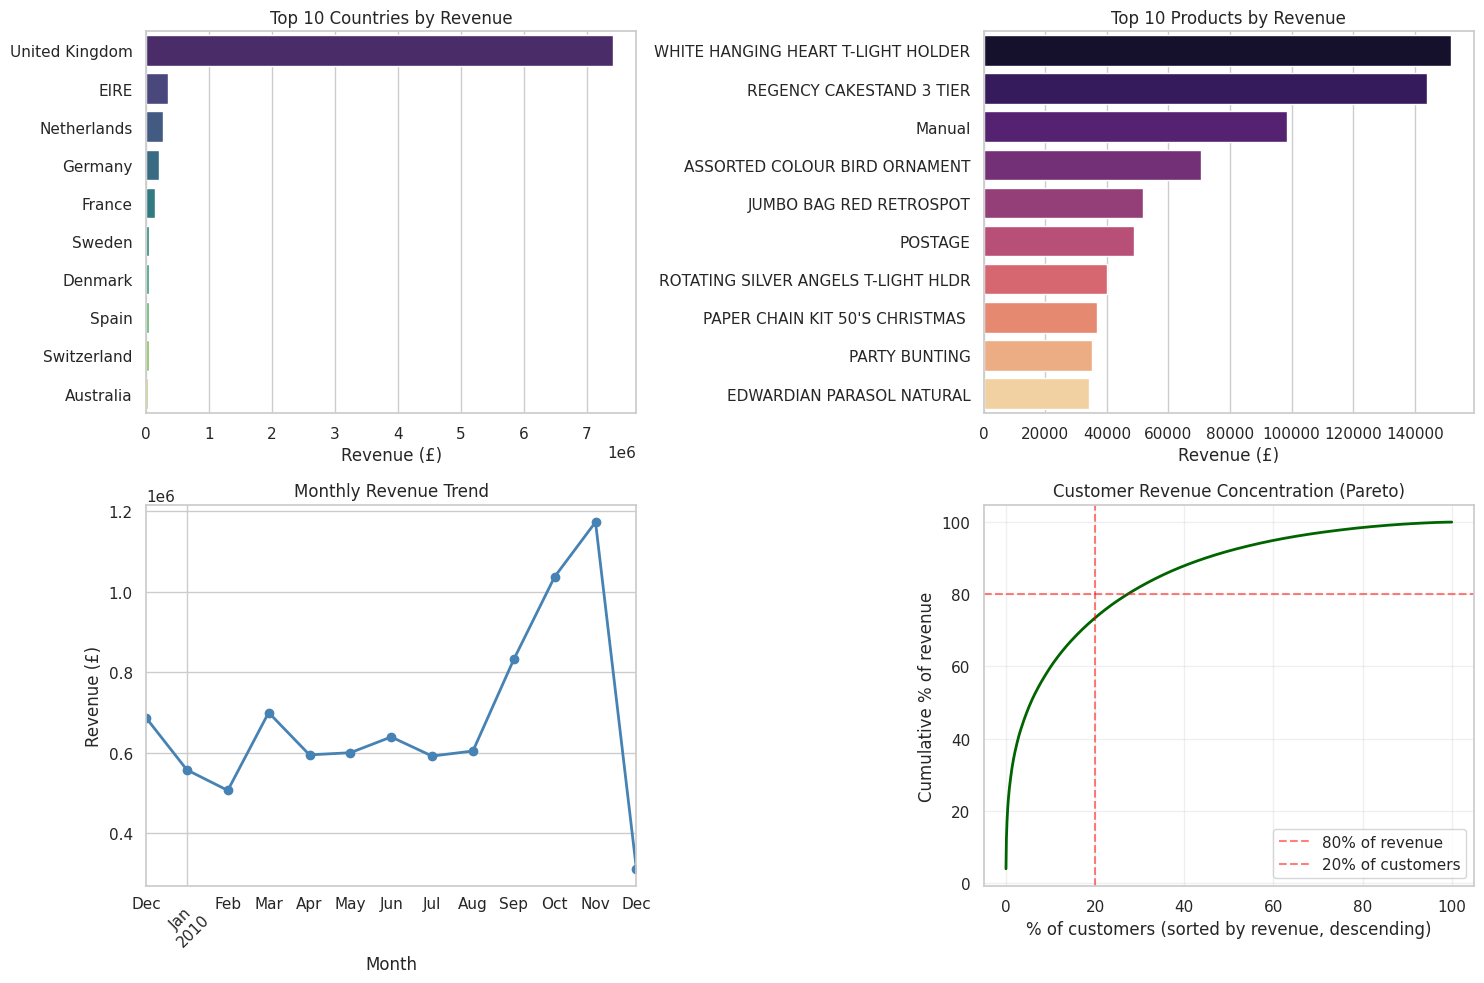

Top 20% of customers generate 73.5% of revenue
Top 1% of customers generate 28.7% of revenue


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# A. Top countries by revenue
country_rev = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_rev.values, y=country_rev.index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Top 10 Countries by Revenue')
axes[0,0].set_xlabel('Revenue (£)')
axes[0,0].set_ylabel('')

# B. Top products by revenue
top_prod = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_prod.values, y=top_prod.index, ax=axes[0,1], palette='magma')
axes[0,1].set_title('Top 10 Products by Revenue')
axes[0,1].set_xlabel('Revenue (£)')
axes[0,1].set_ylabel('')

# C. Monthly revenue trend
monthly = df_clean.groupby('YearMonth')['Revenue'].sum()
monthly.plot(marker='o', ax=axes[1,0], color='steelblue', linewidth=2)
axes[1,0].set_title('Monthly Revenue Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Revenue (£)')
axes[1,0].tick_params(axis='x', rotation=45)

# D. Customer revenue concentration (Pareto)
cust_rev = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
cum_pct = 100 * cust_rev.cumsum() / cust_rev.sum()
axes[1,1].plot(np.arange(len(cust_rev)) / len(cust_rev) * 100, cum_pct.values, color='darkgreen', linewidth=2)
axes[1,1].axhline(80, color='red', linestyle='--', alpha=0.5, label='80% of revenue')
axes[1,1].axvline(20, color='red', linestyle='--', alpha=0.5, label='20% of customers')
axes[1,1].set_title('Customer Revenue Concentration (Pareto)')
axes[1,1].set_xlabel('% of customers (sorted by revenue, descending)')
axes[1,1].set_ylabel('Cumulative % of revenue')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Pareto numbers
top20_pct_share = cum_pct.iloc[int(0.2 * len(cust_rev))]
print(f'Top 20% of customers generate {top20_pct_share:.1f}% of revenue')
print(f'Top 1% of customers generate {cum_pct.iloc[int(0.01 * len(cust_rev))]:.1f}% of revenue')

**Insights from EDA:**
- Revenue is highly concentrated in the UK (the home market) with international expansion is largely untapped.
- Customer revenue follows a **Pareto distribution** with the top 20% of customers generate the bulk of revenue. This is why per-customer LTV modeling matters as misallocating retention budget toward the bottom 80% can lead wasting money the top 20% would have repaid 10×.
- The monthly trend shows clear seasonality (holiday spike in Nov-Dec). Any model trained without time-aware splits will be optimistic and I will handle this in the evaluation section.

# 3. Customer-Level Feature Engineering

**Customer-Level Table**: one row per customer with their RFM (Recency, Frequency, Monetary) profile plus tenure, AOV and purchase cadence. Raw transactions are at line-item grain then aggregated up.

**Rationale**: RFM are the dominant predictors of repeat purchase behavior in non-contractual retail. Tenure separates new from established customers, AOV captures spend-per-order and inter-purchase gap captures cadence stability.

In [6]:
customer_df = df_clean.groupby('Customer ID').agg(
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    frequency=('Invoice', 'nunique'),       # number of distinct orders
    total_revenue=('Revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    n_unique_items=('StockCode', 'nunique'),
    country=('Country', lambda x: x.mode()[0])
).reset_index()

customer_df['recency_days'] = (snapshot_date - customer_df['last_purchase']).dt.days
customer_df['tenure_days'] = (snapshot_date - customer_df['first_purchase']).dt.days
customer_df['aov'] = customer_df['total_revenue'] / customer_df['frequency']
customer_df['avg_inter_purchase_days'] = np.where(
    customer_df['frequency'] > 1,
    (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days / (customer_df['frequency'] - 1),
    np.nan
)

print(f'Customer-level table: {customer_df.shape[0]:,} customers, {customer_df.shape[1]} features')
customer_df.head()

Customer-level table: 4,312 customers, 12 features


,Customer ID,first_purchase,last_purchase,frequency,total_revenue,total_quantity,n_unique_items,country,recency_days,tenure_days,aov,avg_inter_purchase_days
0,12346,2009-12-14 08:34:00,2010-06-28 13:53:00,11,372.86,70,26,United Kingdom,165,361,33.896364,19.6
1,12347,2010-10-31 14:20:00,2010-12-07 14:57:00,2,1323.32,828,70,Iceland,3,40,661.660000,37.0
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,222.16,373,20,Finland,74,74,222.160000,NaN
3,12349,2010-04-29 13:20:00,2010-10-28 08:23:00,3,2671.14,993,90,Italy,43,225,890.380000,90.5
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,261,21,Unspecified,11,11,300.930000,NaN


# 4. Customer Segmentation — RFM Scoring + K-Means Clustering

1. **RFM scoring (rule-based)**: quintile each of R, F, M and combine into named segments (Champions, Loyal, At Risk, Lost, etc.).

2. **K-Means clustering** : discovers segments from the data instead of hard-coding quintile rules. Picked `k` using the elbow method and silhouette score.

These two views typically agree on the obvious cases (Champions, Lost) and disagree at the boundaries which will provide a more comprehensive view.

## 4.1 RFM Quintile Scoring

Each customer gets a score from 1 (worst) to 5 (best) on Recency, Frequency, and Monetary value. Combinations map to named business segments.

In [7]:
rfm = customer_df[['Customer ID', 'recency_days', 'frequency', 'total_revenue']].copy()

# Quintile scores (5 = best). For recency, lower is better, so we invert.
rfm['R_score'] = pd.qcut(rfm['recency_days'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['total_revenue'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_sum'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Map combinations to standard named segments (industry convention)
def segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    if r >= 3 and f >= 4:
        return 'Loyal Customers'
    if r >= 4 and f <= 2:
        return 'New Customers'
    if r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    if r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    if r <= 2 and f >= 4:
        return "Can't Lose Them"
    if r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    if r <= 2 and f <= 2:
        return 'Hibernating'
    return 'Needs Attention'

rfm['segment'] = rfm.apply(segment, axis=1)

# Segment summary
seg_summary = rfm.groupby('segment').agg(
    customers=('Customer ID', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    total_revenue=('total_revenue', 'sum')
).round(1).sort_values('total_revenue', ascending=False)
seg_summary['% of customers'] = (100 * seg_summary['customers'] / seg_summary['customers'].sum()).round(1)
seg_summary['% of revenue'] = (100 * seg_summary['total_revenue'] / seg_summary['total_revenue'].sum()).round(1)

print('RFM Segment Summary:')
print(seg_summary)

RFM Segment Summary:
                     customers  avg_recency  avg_frequency  avg_revenue  total_revenue  % of customers  % of revenue
segment                                                                                                             
Champions                  911         13.3           11.7       6218.5      5665079.8            21.1          64.1
Loyal Customers            488         39.2            5.4       1836.1       896028.9            11.3          10.1
At Risk                    220        125.8            6.0       3112.4       684725.0             5.1           7.8
Needs Attention            812         98.2            1.9        579.3       470411.6            18.8           5.3
Potential Loyalists        390         35.7            2.4       1170.9       456665.0             9.0           5.2
Hibernating                188        180.7            1.4       1200.0       225594.9             4.4           2.6
Lost                       837        219.6

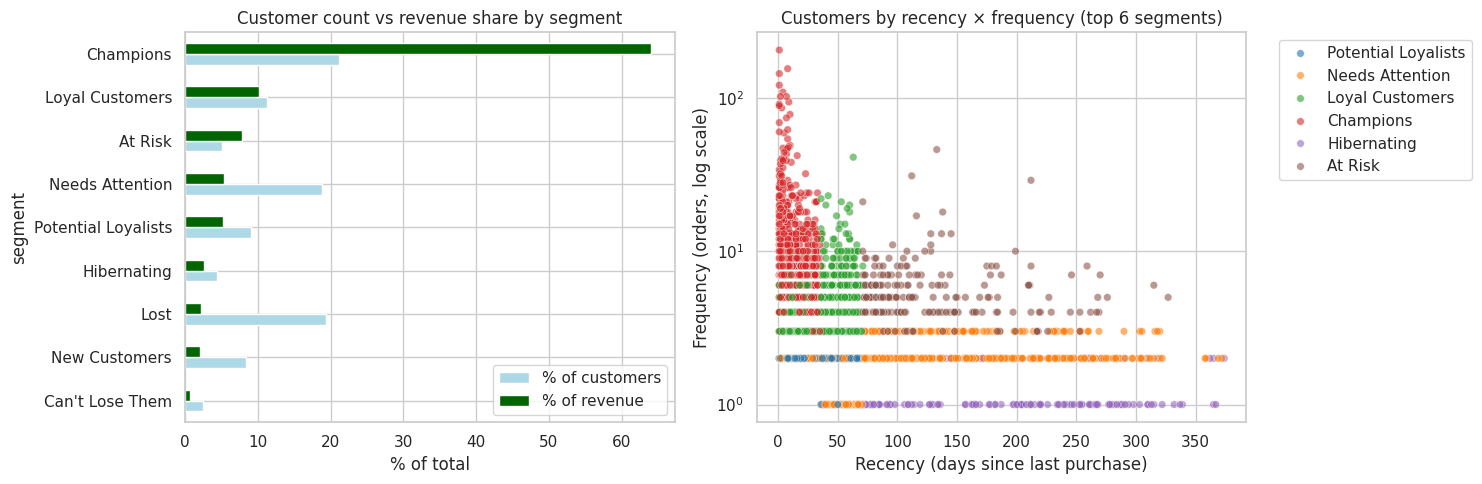

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Customer count and revenue share by segment
seg_plot = seg_summary[['% of customers', '% of revenue']].sort_values('% of revenue', ascending=True)
seg_plot.plot(kind='barh', ax=axes[0], color=['lightblue', 'darkgreen'])
axes[0].set_title('Customer count vs revenue share by segment')
axes[0].set_xlabel('% of total')
axes[0].legend(loc='lower right')

# Recency vs frequency colored by segment
top_segs = seg_summary.head(6).index.tolist()
plot_df = rfm[rfm['segment'].isin(top_segs)]
sns.scatterplot(data=plot_df, x='recency_days', y='frequency', hue='segment',
                alpha=0.6, s=30, ax=axes[1], palette='tab10')
axes[1].set_yscale('log')
axes[1].set_title('Customers by recency × frequency (top 6 segments)')
axes[1].set_xlabel('Recency (days since last purchase)')
axes[1].set_ylabel('Frequency (orders, log scale)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4.2 K-Means Clustering

RFM rules-based segmentation arbitrary have rigid  boundaries between quintiles and K-Means lets the data find natural groupings. Picking `k` using the elbow + silhouette method then interpreting each cluster by its RFM profile.

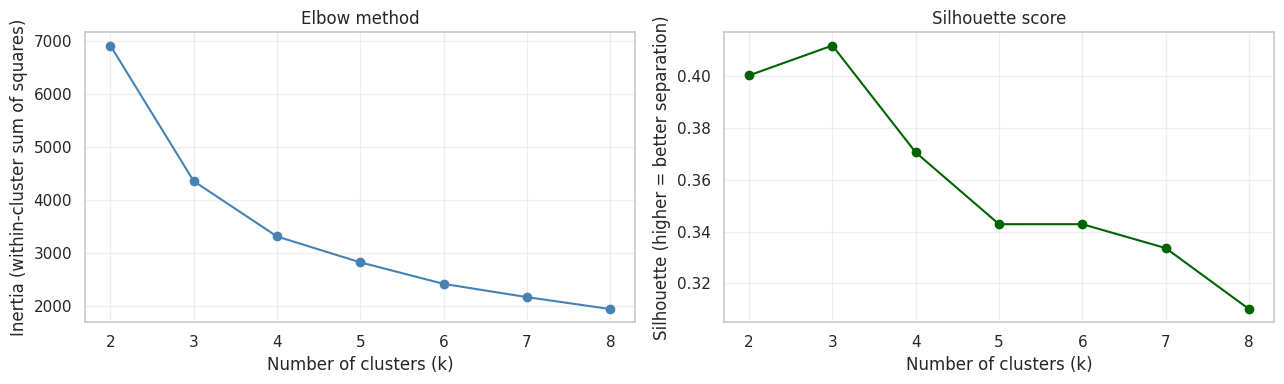

Best k by silhouette: 3  (silhouette=0.412)


In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Use log-transformed RFM features (revenue/frequency are heavy-tailed)
cluster_features = pd.DataFrame({
    'recency': rfm['recency_days'],
    'log_frequency': np.log1p(rfm['frequency']),
    'log_revenue': np.log1p(rfm['total_revenue']),
})
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_features)

# Elbow + silhouette to pick k
inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', color='darkgreen')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette (higher = better separation)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f'Best k by silhouette: {best_k}  (silhouette={max(silhouettes):.3f})')

In [10]:
# Fitting final K-Means with chosen k
K = best_k if best_k <= 5 else 4
kmeans_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
rfm['cluster'] = kmeans_final.fit_predict(X_cluster)

# Profile each cluster — this is the interpretation step
cluster_profile = rfm.groupby('cluster').agg(
    customers=('Customer ID', 'count'),
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_revenue=('total_revenue', 'mean'),
    total_revenue=('total_revenue', 'sum'),
).round(1)
cluster_profile['% of customers'] = (100 * cluster_profile['customers'] / cluster_profile['customers'].sum()).round(1)
cluster_profile['% of revenue'] = (100 * cluster_profile['total_revenue'] / cluster_profile['total_revenue'].sum()).round(1)
cluster_profile = cluster_profile.sort_values('avg_revenue', ascending=False)

# Auto-name clusters by their RFM profile
def name_cluster(row, recency_median, freq_median, rev_median):
    name = []
    name.append('High-value' if row['avg_revenue'] > rev_median else 'Low-value')
    name.append('Active' if row['avg_recency'] < recency_median else 'Dormant')
    return ' / '.join(name)

med_r = cluster_profile['avg_recency'].median()
med_f = cluster_profile['avg_frequency'].median()
med_rev = cluster_profile['avg_revenue'].median()
cluster_profile['cluster_label'] = cluster_profile.apply(
    lambda r: name_cluster(r, med_r, med_f, med_rev), axis=1)

print(f'K-Means cluster profile (k={K}):')
print(cluster_profile)

# Map cluster IDs to labels in main rfm table for downstream use
cluster_id_to_label = cluster_profile['cluster_label'].to_dict()
rfm['cluster_label'] = rfm['cluster'].map(cluster_id_to_label)

K-Means cluster profile (k=3):
         customers  avg_recency  avg_frequency  avg_revenue  total_revenue  % of customers  % of revenue        cluster_label
cluster                                                                                                                      
0             1361         34.1           10.1       5267.6      7169255.8            31.6          81.2  High-value / Active
2             1996         54.2            2.1        630.8      1259104.4            46.3          14.3  Low-value / Dormant
1              955        249.8            1.4        422.7       403643.1            22.1           4.6  Low-value / Dormant


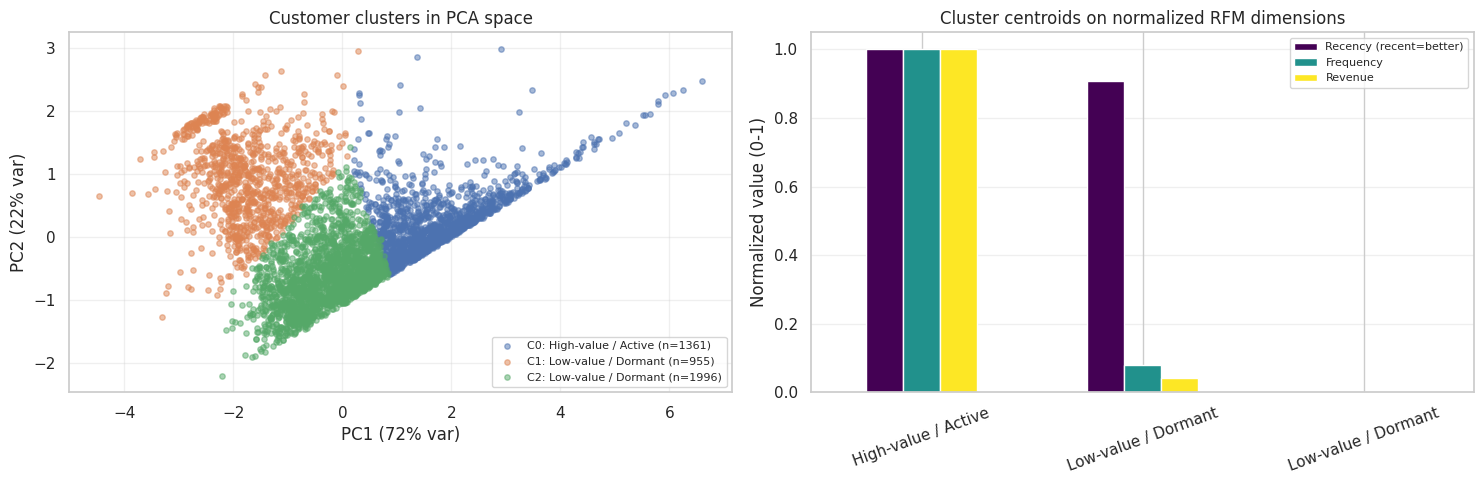

In [11]:
# Visualize clusters in 2D PCA space
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PCA scatter
for cid in sorted(rfm['cluster'].unique()):
    mask = rfm['cluster'] == cid
    label = cluster_id_to_label[cid]
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=15,
                    label=f'C{cid}: {label} (n={mask.sum()})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)')
axes[0].set_title('Customer clusters in PCA space')
axes[0].legend(fontsize=8, loc='best')
axes[0].grid(alpha=0.3)

# Cluster centroids on RFM axes (radar-style bar chart)
centroid_df = cluster_profile[['avg_recency', 'avg_frequency', 'avg_revenue']].copy()
# Normalize to 0-1 for comparability (invert recency since lower is better)
centroid_norm = centroid_df.copy()
centroid_norm['avg_recency'] = 1 - (centroid_norm['avg_recency'] - centroid_norm['avg_recency'].min()) / \
    (centroid_norm['avg_recency'].max() - centroid_norm['avg_recency'].min() + 1e-9)
centroid_norm['avg_frequency'] = (centroid_norm['avg_frequency'] - centroid_norm['avg_frequency'].min()) / \
    (centroid_norm['avg_frequency'].max() - centroid_norm['avg_frequency'].min() + 1e-9)
centroid_norm['avg_revenue'] = (centroid_norm['avg_revenue'] - centroid_norm['avg_revenue'].min()) / \
    (centroid_norm['avg_revenue'].max() - centroid_norm['avg_revenue'].min() + 1e-9)

centroid_norm.columns = ['Recency (recent=better)', 'Frequency', 'Revenue']
centroid_norm.index = [cluster_id_to_label[i] for i in centroid_norm.index]
centroid_norm.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Cluster centroids on normalized RFM dimensions')
axes[1].set_ylabel('Normalized value (0-1)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [12]:
# Merge segmentation results back into customer_df for use throughout the rest of the notebook
customer_df = customer_df.merge(
    rfm[['Customer ID', 'segment', 'cluster_label', 'R_score', 'F_score', 'M_score']],
    on='Customer ID', how='left'
)
print('customer_df now includes segmentation columns:')
print(customer_df[['Customer ID', 'recency_days', 'frequency', 'total_revenue', 'segment', 'cluster_label']].head())

customer_df now includes segmentation columns:
   Customer ID  recency_days  frequency  total_revenue              segment        cluster_label
0        12346           165         11         372.86      Can't Lose Them  High-value / Active
1        12347             3          2        1323.32        New Customers  Low-value / Dormant
2        12348            74          1         222.16                 Lost  Low-value / Dormant
3        12349            43          3        2671.14  Potential Loyalists  High-value / Active
4        12351            11          1         300.93        New Customers  Low-value / Dormant


# 5. Retention Modeling

**Question:** *Which customers will come back in the next 60 days?*

## 5.1 Retention — Statistical: Kaplan-Meier + Cox Proportional Hazards

Kaplan-Meier (KM) estimates `S(t) = P(customer still active at time t)` without parametric assumptions. Cox PH extends this by quantifying how covariates (frequency, AOV, country) shift the hazard of churn. Together they answer: *how long do customers stay, and what makes them stay longer?*

Customers in survival analysis: 3,290
Churned (event=1): 913 (27.8%)
Censored (still active): 2,377


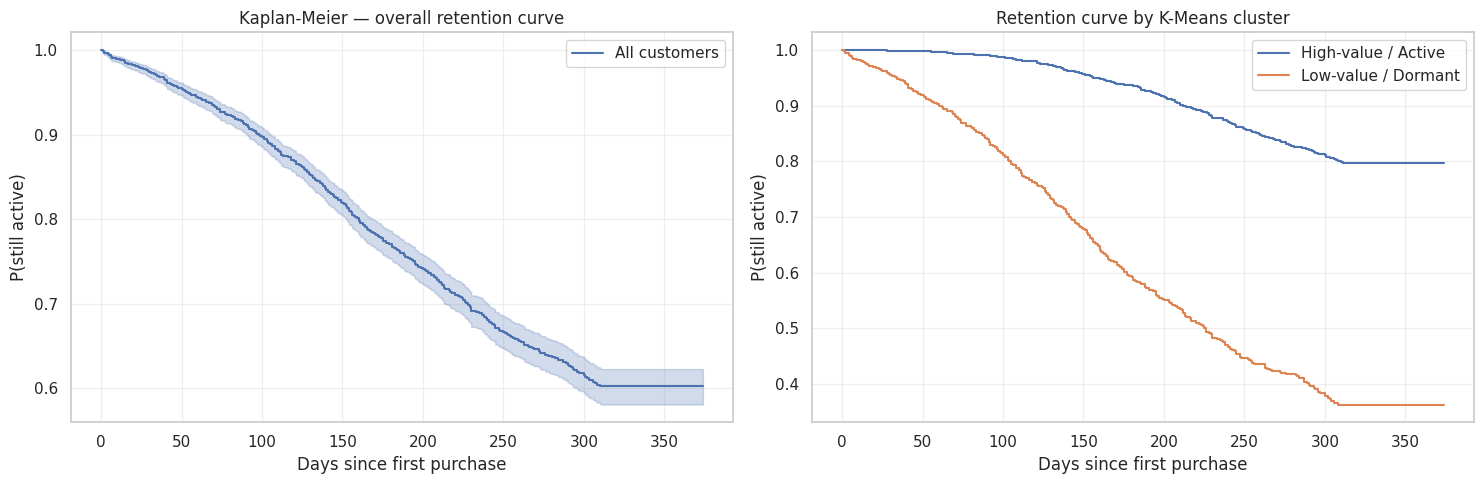


Median time-to-churn (overall): inf days
Survival at 30 days:  0.974
Survival at 60 days:  0.943
Survival at 180 days: 0.770


In [13]:
try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifelines'])
    from lifelines import KaplanMeierFitter, CoxPHFitter

surv_df = customer_df.copy()
surv_df['event'] = (surv_df['recency_days'] > CHURN_THRESHOLD_DAYS).astype(int)
surv_df['duration'] = np.where(
    surv_df['event'] == 1,
    (surv_df['last_purchase'] - surv_df['first_purchase']).dt.days,
    surv_df['tenure_days']
)
surv_df = surv_df[surv_df['duration'] > 0].copy()

print(f'Customers in survival analysis: {len(surv_df):,}')
print(f'Churned (event=1): {surv_df["event"].sum():,} ({surv_df["event"].mean()*100:.1f}%)')
print(f'Censored (still active): {(surv_df["event"]==0).sum():,}')

# Kaplan-Meier — overall + by cluster
kmf = KaplanMeierFitter()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

kmf.fit(surv_df['duration'], surv_df['event'], label='All customers')
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title('Kaplan-Meier — overall retention curve')
axes[0].set_xlabel('Days since first purchase')
axes[0].set_ylabel('P(still active)')
axes[0].grid(alpha=0.3)

# By cluster — shows whether segments retain differently
for cluster_label in surv_df['cluster_label'].dropna().unique():
    sub = surv_df[surv_df['cluster_label'] == cluster_label]
    if len(sub) > 30:
        kmf_c = KaplanMeierFitter()
        kmf_c.fit(sub['duration'], sub['event'], label=cluster_label)
        kmf_c.plot_survival_function(ax=axes[1], ci_show=False)
axes[1].set_title('Retention curve by K-Means cluster')
axes[1].set_xlabel('Days since first purchase')
axes[1].set_ylabel('P(still active)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nMedian time-to-churn (overall): {kmf.median_survival_time_} days')
print(f'Survival at 30 days:  {float(kmf.survival_function_at_times(30).iloc[0]):.3f}')
print(f'Survival at 60 days:  {float(kmf.survival_function_at_times(60).iloc[0]):.3f}')
print(f'Survival at 180 days: {float(kmf.survival_function_at_times(180).iloc[0]):.3f}')

Cox PH summary:


<lifelines.CoxPHFitter: fitted with 3290 total observations, 2377 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 3290
number of events observed = 913
   partial log-likelihood = -6571.42
         time fit was run = 2026-05-06 16:33:11 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
n_unique_items -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
is_uk          -0.09      0.92      0.13           -0.33            0.16                0.72                1.17
log_aov         0.00      1.00      0.05           -0.11            0.11                0.90                1.11
log_frequency  -1.45      0.23      0.09           -1.63           -1.27                0.20                0.28

                cmp to      z      p  -log2(p)
covariate                                     
n_unique_items    0.00  -5.74 <0.005     26.66
is_uk             0.00  -0.70   0.49      1.04
log_aov           0.00   0.02   0.99      0.02
log_frequency     0.00 -15.76 <0.005    183.52
---
Concordance = 0.74
Partial AIC = 13150.84
log-likelihood ratio test = 643.01 on 4 df
-log2(p) of ll-ratio test = 455.50

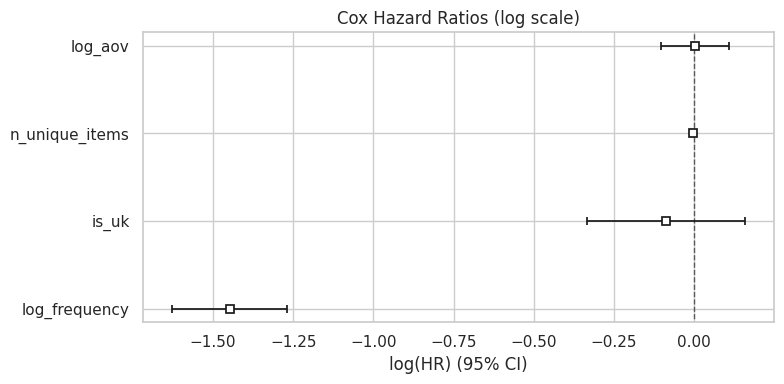


Concordance index: 0.744  (0.5=random, 0.7+=useful, 0.8+=strong)


In [14]:
# Cox Proportional Hazards — quantifies which features drive churn
cox_df = surv_df[['duration', 'event', 'frequency', 'aov', 'n_unique_items', 'country']].copy()
cox_df['is_uk'] = (cox_df['country'] == 'United Kingdom').astype(int)
cox_df = cox_df.drop(columns=['country'])
cox_df['log_aov'] = np.log1p(cox_df['aov'])
cox_df['log_frequency'] = np.log1p(cox_df['frequency'])
cox_df = cox_df.drop(columns=['aov', 'frequency'])

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration', event_col='event')
print('Cox PH summary:')
cph.print_summary()

fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
ax.set_title('Cox Hazard Ratios (log scale)')
plt.tight_layout()
plt.show()

print(f'\nConcordance index: {cph.concordance_index_:.3f}  (0.5=random, 0.7+=useful, 0.8+=strong)')

## 5.2 Retention — Machine Learning: Logistic Regression

Logistic regression serve as baseline for binary retention classification. I tune the regularization strength with cross-validation rather than accepting defaults

In [15]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, confusion_matrix

# Time-aware split
cutoff = snapshot_date - pd.Timedelta(days=WINDOW_DAYS)
feature_tx = df_clean[df_clean['InvoiceDate'] < cutoff].copy()
outcome_tx = df_clean[df_clean['InvoiceDate'] >= cutoff].copy()

# Build features only from feature window
feat = feature_tx.groupby('Customer ID').agg(
    frequency=('Invoice', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    n_unique_items=('StockCode', 'nunique'),
    last_purchase=('InvoiceDate', 'max'),
    first_purchase=('InvoiceDate', 'min'),
).reset_index()
feat['recency'] = (cutoff - feat['last_purchase']).dt.days
feat['tenure'] = (cutoff - feat['first_purchase']).dt.days
feat['aov'] = feat['total_revenue'] / feat['frequency']
feat['log_revenue'] = np.log1p(feat['total_revenue'])
feat['log_frequency'] = np.log1p(feat['frequency'])

# Label: 1 if customer transacted in outcome window
active_in_outcome = set(outcome_tx['Customer ID'].unique())
feat['retained'] = feat['Customer ID'].isin(active_in_outcome).astype(int)

feature_cols = ['recency', 'tenure', 'log_frequency', 'log_revenue', 'aov', 'n_unique_items']
X = feat[feature_cols].fillna(0)
y = feat['retained']
print(f'Retention base rate: {y.mean()*100:.1f}%   N = {len(y):,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Regularization strength via internal CV (this is the optimization step)
lr_cv = LogisticRegressionCV(
    Cs=10, cv=5, max_iter=2000, class_weight='balanced',
    scoring='roc_auc', random_state=RANDOM_STATE
)
lr_cv.fit(X_train_s, y_train)
print(f'Best C (regularization, smaller=stronger): {lr_cv.C_[0]:.4f}')

p_test = lr_cv.predict_proba(X_test_s)[:, 1]
y_pred = (p_test >= 0.5).astype(int)

retention_auc_lr = roc_auc_score(y_test, p_test)
print(f'\nROC-AUC: {retention_auc_lr:.3f}')
print(classification_report(y_test, y_pred, digits=3))

# Standardized coefficients (odds ratios)
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': lr_cv.coef_[0],
    'odds_ratio': np.exp(lr_cv.coef_[0])
}).sort_values('coef', ascending=False)
print('\nStandardized coefficients:')
print(coef_df.to_string(index=False))

Retention base rate: 47.1%   N = 3,701
Best C (regularization, smaller=stronger): 0.0464

ROC-AUC: 0.742
              precision    recall  f1-score   support

           0      0.701     0.712     0.706       490
           1      0.671     0.658     0.664       436

    accuracy                          0.687       926
   macro avg      0.686     0.685     0.685       926
weighted avg      0.687     0.687     0.687       926


Standardized coefficients:
       feature      coef  odds_ratio
n_unique_items  0.433261    1.542279
 log_frequency  0.365641    1.441438
   log_revenue  0.198818    1.219960
        tenure  0.055377    1.056939
           aov -0.156195    0.855392
       recency -0.184217    0.831755


Cost-optimal threshold: 0.008
  (At p_churn > 0.008, expected savings exceed email cost)


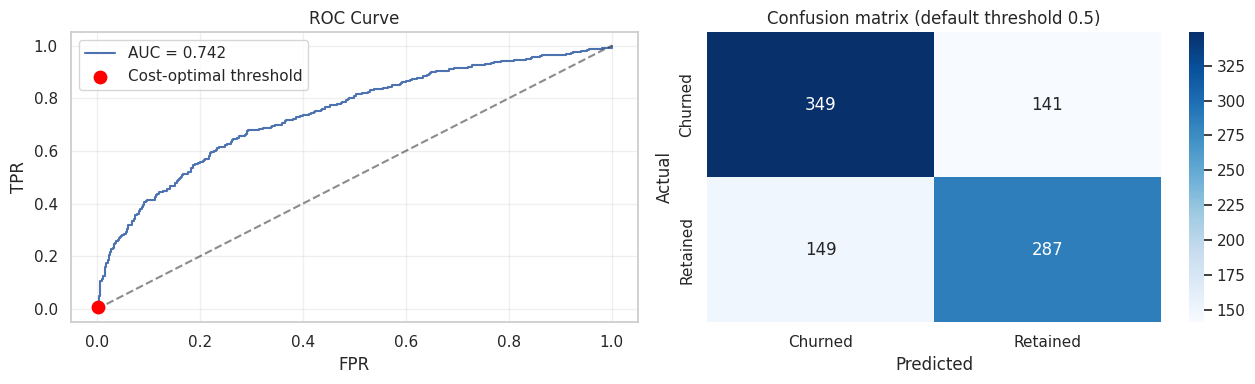

In [16]:
# Default 0.5 is rarely correct: it implicitly assumes false positives and false negatives
# cost the same. In retention they don't.
# Assume: a retention email costs 0.20, an at-risk customer is worth 25 dollars on average.
# Then email anyone with churn-prob * customer_value > email cost.
# Equivalently, threshold p = email_cost / customer_value.
EMAIL_COST = 0.20
CUSTOMER_VALUE = 25.0
optimal_threshold = EMAIL_COST / CUSTOMER_VALUE
print(f'Cost-optimal threshold: {optimal_threshold:.3f}')
print(f'  (At p_churn > {optimal_threshold:.3f}, expected savings exceed email cost)')

# ROC + threshold marker + confusion matrix
fpr, tpr, thresholds = roc_curve(y_test, p_test)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(fpr, tpr, label=f'AUC = {retention_auc_lr:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
# mark the cost-optimal threshold on the ROC
idx_opt = np.argmin(np.abs(thresholds - (1 - optimal_threshold)))  # we predicted retained, threshold on retained
axes[0].scatter(fpr[idx_opt], tpr[idx_opt], color='red', s=80, zorder=5,
                label=f'Cost-optimal threshold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Churned', 'Retained'],
            yticklabels=['Churned', 'Retained'])
axes[1].set_title('Confusion matrix (default threshold 0.5)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 5.3 Retention — Deep Learning: GRU with Attention (early stopping + LR scheduler)

A GRU reads the trajectory of monthly behavior and learns which patterns of acceleration/deceleration predict 60-day retention. Attention pooling weights the most informative months per customer.

In [17]:
try:
    import torch
    import torch.nn as nn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch'])
    import torch
    import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Monthly sequences from PRE-cutoff data only
ret_seq_src = (df_clean[df_clean['InvoiceDate'] < cutoff]
               .assign(ym=lambda d: d['InvoiceDate'].dt.to_period('M'))
               .groupby(['Customer ID', 'ym'])
               .agg(n_invoices=('Invoice', 'nunique'),
                    revenue=('Revenue', 'sum'),
                    n_items=('Quantity', 'sum'))
               .reset_index())

MAX_LEN = 12
FEAT_DIM = 3

def build_padded(group):
    g = group.sort_values('ym').tail(MAX_LEN)
    seq = np.log1p(g[['n_invoices', 'revenue', 'n_items']].values).astype(np.float32)
    pad = MAX_LEN - len(seq)
    mask = np.concatenate([np.zeros(pad, dtype=bool), np.ones(len(g), dtype=bool)])
    if pad > 0:
        seq = np.vstack([np.zeros((pad, FEAT_DIM), dtype=np.float32), seq])
    return seq, mask

ret_X, ret_M, ret_y, ret_cids = [], [], [], []
for cid, grp in ret_seq_src.groupby('Customer ID'):
    s, m = build_padded(grp)
    ret_X.append(s); ret_M.append(m); ret_cids.append(cid)
    ret_y.append(int(cid in active_in_outcome))

ret_X = np.stack(ret_X); ret_M = np.stack(ret_M); ret_y = np.array(ret_y, dtype=np.float32)
print(f'GRU input: X={ret_X.shape}, retention rate={ret_y.mean()*100:.1f}%')

GRU input: X=(3701, 12, 3), retention rate=47.1%


In [18]:
# Train/val/test split for proper early stopping
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.permutation(len(ret_y))
n = len(idx)
tr_end = int(0.65 * n)
va_end = int(0.80 * n)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]
print(f'Train: {len(tr)}, Val: {len(va)}, Test: {len(te)}')

class RetSeqDS(Dataset):
    def __init__(self, X, M, y): self.X, self.M, self.y = X, M, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i]),
                torch.from_numpy(self.M[i].astype(np.float32)),
                torch.tensor(self.y[i]))

tr_dl = DataLoader(RetSeqDS(ret_X[tr], ret_M[tr], ret_y[tr]), batch_size=128, shuffle=True)
va_dl = DataLoader(RetSeqDS(ret_X[va], ret_M[va], ret_y[va]), batch_size=256)
te_dl = DataLoader(RetSeqDS(ret_X[te], ret_M[te], ret_y[te]), batch_size=256)

class RetentionGRU(nn.Module):
    def __init__(self, feat_dim=3, hidden=32, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=1, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden * 2, 1)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )
    def forward(self, x, mask, return_attn=False):
        h, _ = self.gru(x)
        scores = self.attn(h).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1)
        pooled = (h * weights.unsqueeze(-1)).sum(dim=1)
        logit = self.head(pooled).squeeze(-1)
        if return_attn:
            return logit, weights
        return logit

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_STATE)
model = RetentionGRU().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
loss_fn = nn.BCEWithLogitsLoss()

def eval_loader(dl):
    model.eval(); probs, ys = [], []
    with torch.no_grad():
        for X, M, y in dl:
            X, M = X.to(device), M.to(device)
            probs.append(torch.sigmoid(model(X, M)).cpu().numpy())
            ys.append(y.numpy())
    return roc_auc_score(np.concatenate(ys), np.concatenate(probs))

best_val_auc = 0.0
best_state = None
patience = 4
no_improve = 0
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train(); tot = 0
    for X, M, y in tr_dl:
        X, M, y = X.to(device), M.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(X, M), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        opt.step()
        tot += loss.item() * len(y)
    val_auc = eval_loader(va_dl)
    scheduler.step(val_auc)
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    print(f'Epoch {epoch+1:2d}  train BCE: {tot/len(tr):.4f}  val AUC: {val_auc:.4f}  '
          f'lr={opt.param_groups[0]["lr"]:.5f}{"  (best)" if no_improve == 0 else ""}')
    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}.')
        break

# Restoring best weights
model.load_state_dict(best_state)
test_auc_gru = eval_loader(te_dl)
print(f'\nBest val AUC: {best_val_auc:.3f}')
print(f'Test AUC (GRU): {test_auc_gru:.3f}')

Train: 2405, Val: 555, Test: 741
Epoch  1  train BCE: 0.6860  val AUC: 0.7052  lr=0.00100  (best)
Epoch  2  train BCE: 0.6668  val AUC: 0.7049  lr=0.00100
Epoch  3  train BCE: 0.6401  val AUC: 0.7048  lr=0.00100
Epoch  4  train BCE: 0.6230  val AUC: 0.7054  lr=0.00100  (best)
Epoch  5  train BCE: 0.6201  val AUC: 0.7055  lr=0.00100  (best)
Epoch  6  train BCE: 0.6193  val AUC: 0.7042  lr=0.00100
Epoch  7  train BCE: 0.6133  val AUC: 0.7053  lr=0.00100
Epoch  8  train BCE: 0.6176  val AUC: 0.7060  lr=0.00100  (best)
Epoch  9  train BCE: 0.6138  val AUC: 0.7065  lr=0.00100  (best)
Epoch 10  train BCE: 0.6148  val AUC: 0.7062  lr=0.00100
Epoch 11  train BCE: 0.6125  val AUC: 0.7061  lr=0.00100
Epoch 12  train BCE: 0.6144  val AUC: 0.7068  lr=0.00100  (best)
Epoch 13  train BCE: 0.6142  val AUC: 0.7070  lr=0.00100  (best)
Epoch 14  train BCE: 0.6133  val AUC: 0.7069  lr=0.00100
Epoch 15  train BCE: 0.6132  val AUC: 0.7068  lr=0.00100
Epoch 16  train BCE: 0.6161  val AUC: 0.7069  lr=0.00050

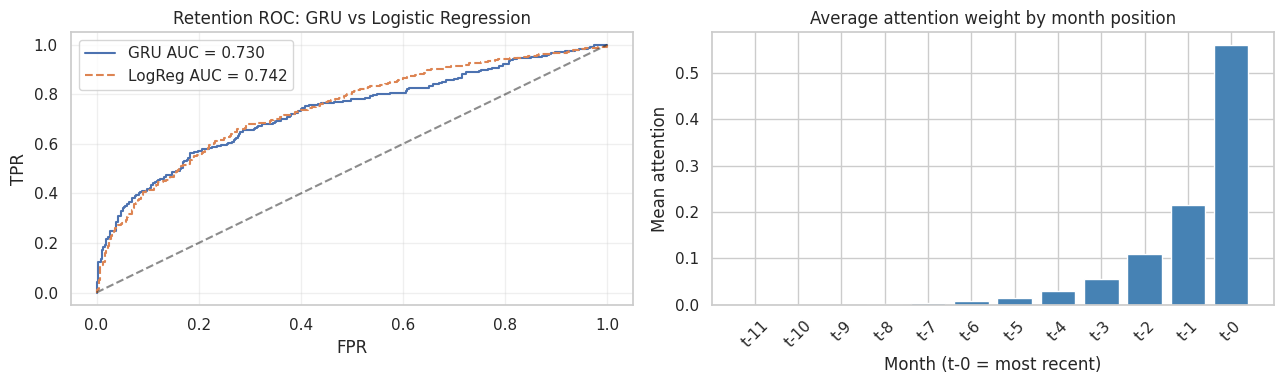

In [19]:
# Attention diagnostic on test set
model.eval(); probs, ys, attn_all = [], [], []
with torch.no_grad():
    for X, M, y in te_dl:
        X, M = X.to(device), M.to(device)
        logit, w = model(X, M, return_attn=True)
        probs.append(torch.sigmoid(logit).cpu().numpy())
        ys.append(y.numpy()); attn_all.append(w.cpu().numpy())
probs = np.concatenate(probs); ys = np.concatenate(ys); attn_all = np.concatenate(attn_all)

avg_attn = attn_all.mean(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fpr_g, tpr_g, _ = roc_curve(ys, probs)
axes[0].plot(fpr_g, tpr_g, label=f'GRU AUC = {test_auc_gru:.3f}')
axes[0].plot(fpr, tpr, label=f'LogReg AUC = {retention_auc_lr:.3f}', linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Retention ROC: GRU vs Logistic Regression')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].bar(range(MAX_LEN), avg_attn, color='steelblue')
axes[1].set_xticks(range(MAX_LEN))
axes[1].set_xticklabels([f't-{MAX_LEN-i-1}' for i in range(MAX_LEN)], rotation=45)
axes[1].set_title('Average attention weight by month position')
axes[1].set_xlabel('Month (t-0 = most recent)')
axes[1].set_ylabel('Mean attention')
plt.tight_layout()
plt.show()

# 6. Churn Modeling

**Question:** *Which active customers are quietly disengaging? Who needs a retention save right now?*

Churn is the flip side of retention but the action is different. Retention is about **predicting who comes back**, churn is about **scoring active customers by leaving risk**.

## 6.1 Churn — Statistical: Weibull AFT

Time-to-churn follows a Weibull distribution and covariates accelerate or decelerate that timeline. Output is interpretable as 'this customer will churn in roughly X days.'

<lifelines.WeibullAFTFitter: fitted with 3290 total observations, 2377 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 3290
number of events observed = 913
           log-likelihood = -6542.95
         time fit was run = 2026-05-06 16:46:59 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                       
lambda_ is_uk           0.07      1.07      0.09           -0.10            0.24                0.90                1.27
        log_aov        -0.01      0.99      0.04           -0.08            0.07                0.92                1.07
        log_frequency   1.00      2.73      0.06            0.89            1.12                2.42                3.07
        n_unique_items  0.00      1.00      0.00            0.00            0.00                1.00                1.00
        Intercept       4.31     74.66      0.25            3.83            4.80               45.96              121.28
rho_    Intercept       0.37      1.45      0.03            0.32            0.42                1.38                1.53

                        cmp to     z      p  -log2(p)
param   covariate                                    
lambda_ is_uk             0.00  0.79   0.43      1.22
        log_aov           0.00 -0.17   0.87      0.21
        log_frequency     0.00 16.57 <0.005    202.44
        n_unique_items    0.00  5.75 <0.005     26.71
        Intercept         0.00 17.42 <0.005    223.42
rho_    Intercept         0.00 14.07 <0.005    147.02
---
Concordance = 0.74
AIC = 13097.90
log-likelihood ratio test = 669.24 on 4 df
-log2(p) of ll-ratio test = 474.36


Risk segment summary (median predicted days-to-churn):
                mean  count
risk_segment               
High risk      156.9    823
Med-high       247.3    822
Med-low        425.1    822
Low risk      8144.8    823


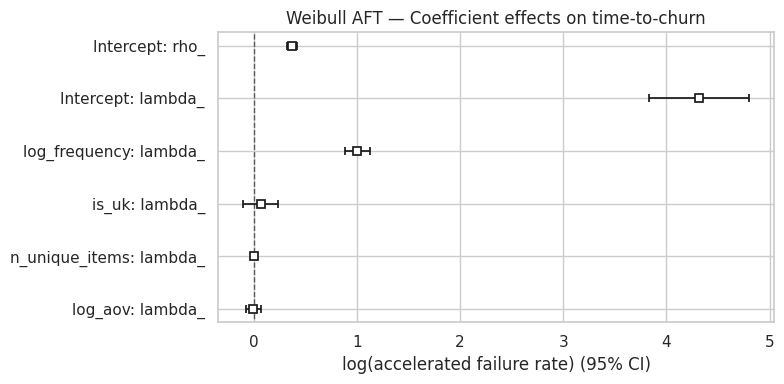

In [20]:
from lifelines import WeibullAFTFitter

aft_df = surv_df[['duration', 'event', 'frequency', 'aov', 'n_unique_items', 'country']].copy()
aft_df['is_uk'] = (aft_df['country'] == 'United Kingdom').astype(int)
aft_df['log_aov'] = np.log1p(aft_df['aov'])
aft_df['log_frequency'] = np.log1p(aft_df['frequency'])
aft_df = aft_df[['duration', 'event', 'log_frequency', 'log_aov', 'n_unique_items', 'is_uk']]

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')
aft.print_summary()

# Predicted median time-to-churn per customer
median_tte = aft.predict_median(aft_df)
aft_df['predicted_median_tte'] = median_tte.values
aft_df['risk_segment'] = pd.qcut(
    aft_df['predicted_median_tte'], q=4,
    labels=['High risk', 'Med-high', 'Med-low', 'Low risk']
)
print('\nRisk segment summary (median predicted days-to-churn):')
print(aft_df.groupby('risk_segment', observed=True)['predicted_median_tte'].agg(['mean', 'count']).round(1))

fig, ax = plt.subplots(figsize=(8, 4))
aft.plot(ax=ax)
ax.set_title('Weibull AFT — Coefficient effects on time-to-churn')
plt.tight_layout()
plt.show()

## 6.2 Churn — Machine Learning: LightGBM + SHAP

LightGBM encompass gradient-boosted decision trees handling non-linearity and feature interactions natively. SHAP makes features explainable down to per-customer level.

In [21]:
try:
    import lightgbm as lgb
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lightgbm', 'shap'])
    import lightgbm as lgb
    import shap

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Reuse the time-aware split; flip label to churn
feat_churn = feat.copy()
feat_churn['churned'] = 1 - feat_churn['retained']

# Engineered interaction features
feat_churn['recency_freq_ratio'] = feat_churn['recency'] / (feat_churn['log_frequency'] + 1)
feat_churn['revenue_per_day'] = feat_churn['total_revenue'] / (feat_churn['tenure'] + 1)

feature_cols_lgb = ['recency', 'tenure', 'log_frequency', 'log_revenue',
                    'aov', 'n_unique_items', 'recency_freq_ratio', 'revenue_per_day']
X = feat_churn[feature_cols_lgb].fillna(0)
y = feat_churn['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Hyperparameter search space
param_dist = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.01, 0.15),
    'num_leaves': randint(15, 80),
    'min_child_samples': randint(10, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 0.5),
}
base_lgbm = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1)
search = RandomizedSearchCV(
    base_lgbm, param_dist, n_iter=20, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train, y_train)
print(f'Best CV AUC: {search.best_score_:.4f}')
print('Best parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

best_lgbm = search.best_estimator_
p_test = best_lgbm.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)
churn_auc_lgbm = roc_auc_score(y_test, p_test)
print(f'\nTest AUC (LightGBM): {churn_auc_lgbm:.3f}')
print(classification_report(y_test, y_pred, digits=3))

Best CV AUC: 0.6767
Best parameters:
  colsample_bytree: 0.836965827544817
  learning_rate: 0.01696756190799966
  min_child_samples: 16
  n_estimators: 220
  num_leaves: 53
  reg_alpha: 0.006632480579933264
  reg_lambda: 0.4711008778424264
  subsample: 0.8253152871382157

Test AUC (LightGBM): 0.733
              precision    recall  f1-score   support

           0      0.695     0.539     0.607       436
           1      0.658     0.790     0.718       490

    accuracy                          0.672       926
   macro avg      0.677     0.664     0.663       926
weighted avg      0.676     0.672     0.666       926



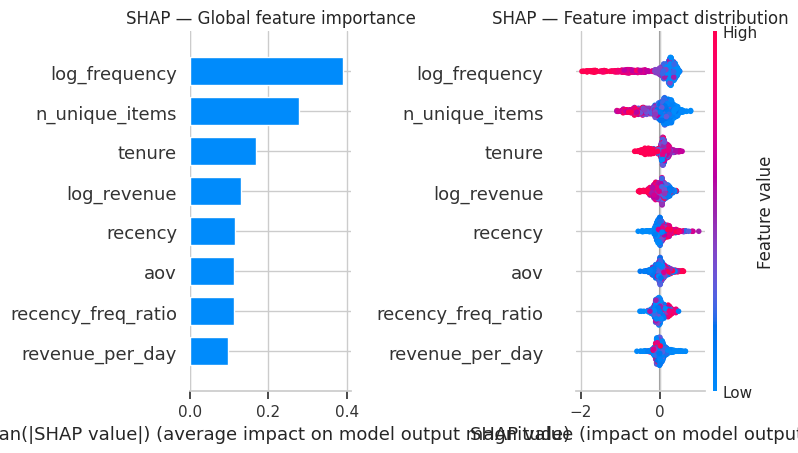

In [22]:
# SHAP global importance
explainer = shap.TreeExplainer(best_lgbm)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
axes[0].set_title('SHAP — Global feature importance')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, show=False)
axes[1].set_title('SHAP — Feature impact distribution')
plt.tight_layout()
plt.show()

## 6.3 Churn — Deep Learning: Transformer Encoder

A transformer reads the actual sequence including month-by-month basket size, revenue and item diversity to learn which patterns predict churn. Self-attention weights events differently per customer, which RFM cannot do.

Sequence tensor: (3701, 12, 3), churn rate: 52.9%
Epoch  1  loss: 0.6943  val AUC: 0.6128  (best)
Epoch  2  loss: 0.6910  val AUC: 0.6333  (best)
Epoch  3  loss: 0.6857  val AUC: 0.6493  (best)
Epoch  4  loss: 0.6775  val AUC: 0.6688  (best)
Epoch  5  loss: 0.6611  val AUC: 0.6799  (best)
Epoch  6  loss: 0.6571  val AUC: 0.6856  (best)
Epoch  7  loss: 0.6471  val AUC: 0.6920  (best)
Epoch  8  loss: 0.6325  val AUC: 0.6939  (best)
Epoch  9  loss: 0.6417  val AUC: 0.7032  (best)
Epoch 10  loss: 0.6300  val AUC: 0.6995
Epoch 11  loss: 0.6256  val AUC: 0.6997
Epoch 12  loss: 0.6288  val AUC: 0.7022
Epoch 13  loss: 0.6215  val AUC: 0.7037  (best)
Epoch 14  loss: 0.6217  val AUC: 0.7032
Epoch 15  loss: 0.6174  val AUC: 0.7038
Epoch 16  loss: 0.6171  val AUC: 0.7041  (best)
Epoch 17  loss: 0.6174  val AUC: 0.7044  (best)
Epoch 18  loss: 0.6172  val AUC: 0.7050  (best)
Epoch 19  loss: 0.6179  val AUC: 0.7047
Epoch 20  loss: 0.6175  val AUC: 0.7049
Epoch 21  loss: 0.6116  val AUC: 0.7051
Epoch 

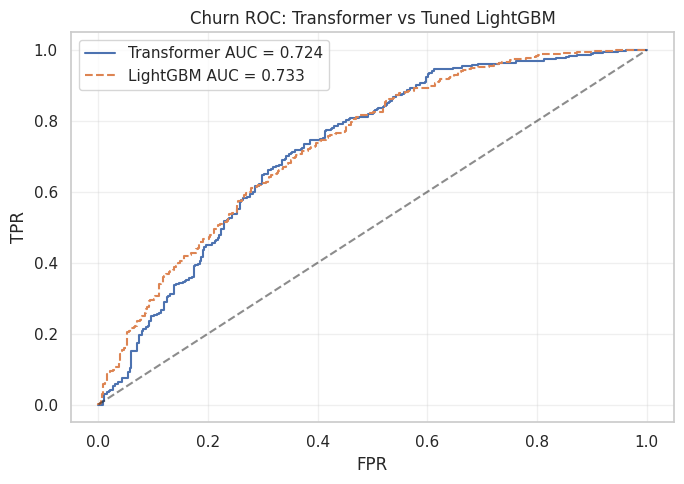

In [23]:
# Monthly sequences using ONLY the feature window to avoid leakage
feat_window_monthly = (df_clean[df_clean['InvoiceDate'] < cutoff]
                       .assign(ym=lambda d: d['InvoiceDate'].dt.to_period('M'))
                       .groupby(['Customer ID', 'ym'])
                       .agg(n_invoices=('Invoice', 'nunique'),
                            revenue=('Revenue', 'sum'),
                            n_items=('Quantity', 'sum'))
                       .reset_index())

def build_sequence(group):
    g = group.sort_values('ym').tail(MAX_LEN)
    seq = np.log1p(g[['n_invoices', 'revenue', 'n_items']].values).astype(np.float32)
    pad_len = MAX_LEN - len(seq)
    mask = np.concatenate([np.zeros(pad_len, dtype=bool), np.ones(len(g), dtype=bool)])
    if pad_len > 0:
        seq = np.vstack([np.zeros((pad_len, FEAT_DIM), dtype=np.float32), seq])
    return seq, mask

seqs, masks, labels, cids = [], [], [], []
for cid, grp in feat_window_monthly.groupby('Customer ID'):
    s, m = build_sequence(grp)
    seqs.append(s); masks.append(m); cids.append(cid)
    labels.append(int(cid not in active_in_outcome))  # churn = 1 - retained

seqs = np.stack(seqs); masks = np.stack(masks); labels = np.array(labels, dtype=np.float32)
print(f'Sequence tensor: {seqs.shape}, churn rate: {labels.mean()*100:.1f}%')

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.permutation(len(labels))
n = len(idx)
tr_end = int(0.65 * n)
va_end = int(0.80 * n)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

class SeqDS(Dataset):
    def __init__(self, X, M, y): self.X, self.M, self.y = X, M, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i]), torch.from_numpy(self.M[i].astype(np.float32)),
                torch.tensor(self.y[i], dtype=torch.float32))

train_dl = DataLoader(SeqDS(seqs[tr], masks[tr], labels[tr]), batch_size=128, shuffle=True)
val_dl   = DataLoader(SeqDS(seqs[va], masks[va], labels[va]), batch_size=256)
test_dl  = DataLoader(SeqDS(seqs[te], masks[te], labels[te]), batch_size=256)

class ChurnTransformer(nn.Module):
    def __init__(self, feat_dim=3, d_model=32, nhead=4, n_layers=2, max_len=12, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(feat_dim, d_model)
        self.pos = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward=64, batch_first=True, dropout=dropout)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))
    def forward(self, x, mask):
        h = self.input_proj(x) + self.pos
        h = self.encoder(h, src_key_padding_mask=~mask.bool())
        m = mask.unsqueeze(-1).float()
        pooled = (h * m).sum(1) / m.sum(1).clamp(min=1)
        return self.head(pooled).squeeze(-1)

torch.manual_seed(RANDOM_STATE)
model = ChurnTransformer().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
loss_fn = nn.BCEWithLogitsLoss()

def eval_seq(dl):
    model.eval(); probs, ys = [], []
    with torch.no_grad():
        for X, M, y in dl:
            X, M = X.to(device), M.to(device)
            probs.append(torch.sigmoid(model(X, M)).cpu().numpy())
            ys.append(y.numpy())
    return roc_auc_score(np.concatenate(ys), np.concatenate(probs))

best_val_auc = 0.0
best_state = None
patience = 4; no_improve = 0
EPOCHS = 25

for epoch in range(EPOCHS):
    model.train(); tot = 0
    for X, M, y in train_dl:
        X, M, y = X.to(device), M.to(device), y.to(device)
        opt.zero_grad()
        logits = model(X, M)
        loss = loss_fn(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tot += loss.item() * len(y)
    val_auc = eval_seq(val_dl)
    scheduler.step(val_auc)
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    print(f'Epoch {epoch+1:2d}  loss: {tot/len(tr):.4f}  val AUC: {val_auc:.4f}'
          f'{"  (best)" if no_improve == 0 else ""}')
    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}.')
        break

model.load_state_dict(best_state)
churn_auc_transformer = eval_seq(test_dl)
print(f'\nBest val AUC: {best_val_auc:.3f}')
print(f'Test AUC (Transformer): {churn_auc_transformer:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
# Pull test predictions for ROC overlay
model.eval(); probs_t, ys_t = [], []
with torch.no_grad():
    for X, M, y in test_dl:
        X, M = X.to(device), M.to(device)
        probs_t.append(torch.sigmoid(model(X, M)).cpu().numpy())
        ys_t.append(y.numpy())
probs_t = np.concatenate(probs_t); ys_t = np.concatenate(ys_t)
fpr_t, tpr_t, _ = roc_curve(ys_t, probs_t)
ax.plot(fpr_t, tpr_t, label=f'Transformer AUC = {churn_auc_transformer:.3f}')
# overlay LightGBM ROC
fpr_l, tpr_l, _ = roc_curve(y_test, p_test)
ax.plot(fpr_l, tpr_l, label=f'LightGBM AUC = {churn_auc_lgbm:.3f}', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Churn ROC: Transformer vs Tuned LightGBM')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. LTV (Lifetime Value) Modeling

**Question:** *How much revenue will each customer generate in the next 60 days? Who's worth investing in?*

LTV is the most directly business-actionable target as it's used to set acquisition cost ceilings, allocate retention budget and decide who gets VIP treatment.

## 7.1 LTV — Statistical: BG/NBD + Gamma-Gamma

1. **BG/NBD**: predicts the *number* of future transactions per customer.
2. **Gamma-Gamma** — predicts the *monetary value* of those transactions.

The product is expected revenue over a forecast window.

**Key assumption:** Gamma-Gamma requires `corr(frequency, monetary_value)` < 0.

In [24]:
try:
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lifetimes'])
    from lifetimes import BetaGeoFitter, GammaGammaFitter
    from lifetimes.utils import summary_data_from_transaction_data

# Lifetimes summary table
lt_input = df_clean.groupby(['Customer ID', 'Invoice', 'InvoiceDate'])['Revenue'].sum().reset_index()
summary = summary_data_from_transaction_data(
    lt_input, 'Customer ID', 'InvoiceDate', monetary_value_col='Revenue',
    observation_period_end=snapshot_date
)
print(f'N customers: {len(summary):,}   N repeat customers: {(summary["frequency"] >= 1).sum():,}')

# Fit BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
print('\nBG/NBD parameters:')
print(bgf.summary)

# Gamma-Gamma repeat customers with positive monetary value
repeat_summary = summary[(summary['frequency'] > 0) & (summary['monetary_value'] > 0)].copy()
freq_mon_corr = repeat_summary[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f'\nFrequency vs monetary_value correlation: {freq_mon_corr:.3f}')
print('(Gamma-Gamma assumes |corr| < 0.1; proceed with caution otherwise)')

ggf = GammaGammaFitter(penalizer_coef=0.1)
ggf.fit(repeat_summary['frequency'], repeat_summary['monetary_value'])
print('\nGamma-Gamma parameters:')
print(ggf.summary)

# CLV forecast over WINDOW_DAYS (60 days)
FORECAST_DAYS = WINDOW_DAYS
clv_summary = summary.copy()
clv_summary['pred_purchases_window'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    FORECAST_DAYS, clv_summary['frequency'], clv_summary['recency'], clv_summary['T']
)
clv_summary['pred_avg_value'] = np.where(
    clv_summary['frequency'] > 0,
    ggf.conditional_expected_average_profit(clv_summary['frequency'], clv_summary['monetary_value']),
    clv_summary['monetary_value']
)
clv_summary['pred_clv_window'] = clv_summary['pred_purchases_window'] * clv_summary['pred_avg_value']

print(f'\nPredicted {FORECAST_DAYS}-day CLV summary:')
print(clv_summary['pred_clv_window'].describe().round(2))

N customers: 4,312   N repeat customers: 2,818

BG/NBD parameters:
               coef      se(coef)  lower 95% bound  upper 95% bound
r      6.155147e-01  1.517683e-02     5.857681e-01     6.452613e-01
alpha  5.081433e+01  1.660210e+00     4.756032e+01     5.406834e+01
a      3.813587e-14  4.791343e-10    -9.390652e-10     9.391414e-10
b      1.925509e-06  2.417920e-02    -4.738930e-02     4.739315e-02

Frequency vs monetary_value correlation: 0.187
(Gamma-Gamma assumes |corr| < 0.1; proceed with caution otherwise)

Gamma-Gamma parameters:
       coef  se(coef)  lower 95% bound  upper 95% bound
p  1.027869  0.029739         0.969581         1.086158
q  0.176990  0.003611         0.169911         0.184068
v  0.927767  0.031061         0.866887         0.988646

Predicted 60-day CLV summary:
count     4312.00
mean       489.57
std       1389.81
min          0.00
25%          0.00
50%        237.99
75%        547.42
max      50676.66
Name: pred_clv_window, dtype: float64


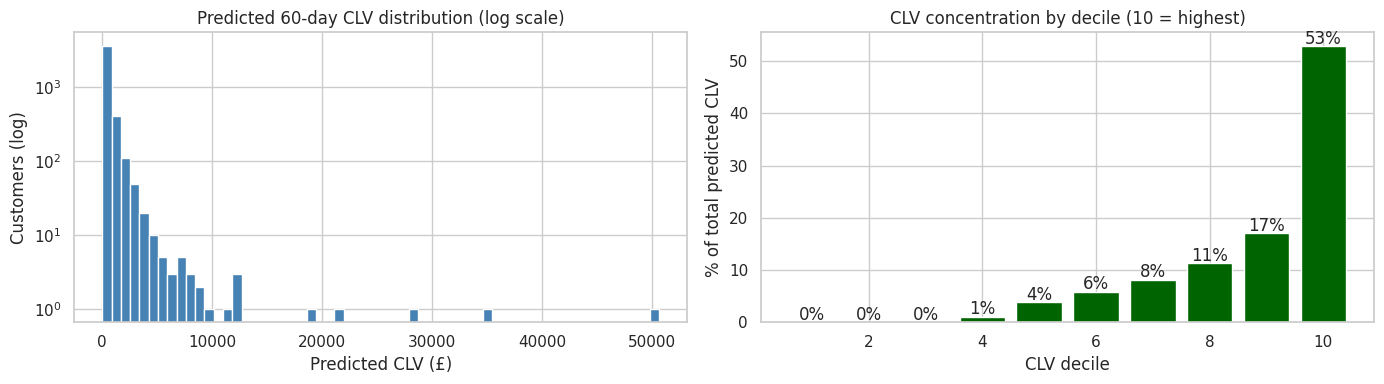


Top decile generates 53% of predicted CLV
Top 10 customers by predicted CLV:
             frequency  recency      T  pred_purchases_window  pred_avg_value  pred_clv_window
Customer ID                                                                                   
18102             42.0    373.0  374.0                   6.02         8419.54         50676.66
14646             45.0    363.0  373.0                   6.46         5490.73         35458.32
14156             78.0    367.0  374.0                  11.10         2532.42         28118.73
14911            127.0    373.0  374.0                  18.02         1199.81         21625.55
13694             48.0    362.0  371.0                   6.92         2731.27         18887.31
16754             18.0    269.0  277.0                   3.41         3669.16         12501.58
16684             18.0    353.0  368.0                   2.67         4613.04         12302.45
17511             24.0    370.0  373.0                   3.48      

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(clv_summary['pred_clv_window'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title(f'Predicted {FORECAST_DAYS}-day CLV distribution (log scale)')
axes[0].set_xlabel('Predicted CLV (£)'); axes[0].set_ylabel('Customers (log)')

# Decile concentration — the headline business chart
clv_summary['decile'] = pd.qcut(clv_summary['pred_clv_window'].rank(method='first'),
                                q=10, labels=range(1, 11))
decile_share = clv_summary.groupby('decile', observed=True)['pred_clv_window'].sum()
decile_share_pct = 100 * decile_share / decile_share.sum()
axes[1].bar(range(1, 11), decile_share_pct.values, color='darkgreen')
axes[1].set_title('CLV concentration by decile (10 = highest)')
axes[1].set_xlabel('CLV decile'); axes[1].set_ylabel('% of total predicted CLV')
for i, v in enumerate(decile_share_pct.values):
    axes[1].text(i+1, v+0.5, f'{v:.0f}%', ha='center')
plt.tight_layout()
plt.show()

print(f'\nTop decile generates {decile_share_pct.iloc[-1]:.0f}% of predicted CLV')
print('Top 10 customers by predicted CLV:')
print(clv_summary.nlargest(10, 'pred_clv_window')[
    ['frequency', 'recency', 'T', 'pred_purchases_window', 'pred_avg_value', 'pred_clv_window']
].round(2))

## 7.2 LTV — Machine Learning: XGBoost Regression

XGBoost learns mapping `(features) → future_revenue` from data, incorporating features BG/NBD ignores (country, item diversity, seasonality) and capturing interactions.

In [26]:
try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# Outcome-window revenue per customer
outcome_rev = outcome_tx.groupby('Customer ID')['Revenue'].sum().rename('future_revenue_window')
ltv_df = feat.merge(outcome_rev, on='Customer ID', how='left').fillna({'future_revenue_window': 0})

feature_cols_ltv = ['recency', 'tenure', 'log_frequency', 'log_revenue',
                    'aov', 'n_unique_items']
X = ltv_df[feature_cols_ltv].fillna(0)
y = ltv_df['future_revenue_window']
y_log = np.log1p(y)

X_train, X_test, ylog_train, ylog_test, y_train, y_test = train_test_split(
    X, y_log, y, test_size=0.25, random_state=RANDOM_STATE
)

# Hyperparameter search
param_dist_xgb = {
    'n_estimators': randint(200, 800),
    'learning_rate': uniform(0.02, 0.15),
    'max_depth': randint(3, 9),
    'min_child_weight': randint(1, 8),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0, 1),
}
base_xgb = XGBRegressor(tree_method='hist', random_state=RANDOM_STATE)
search_xgb = RandomizedSearchCV(
    base_xgb, param_dist_xgb, n_iter=20, cv=3,
    scoring='neg_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search_xgb.fit(X_train, ylog_train)
print(f'Best CV MSE (log space): {-search_xgb.best_score_:.4f}')
print('Best parameters:')
for k, v in search_xgb.best_params_.items():
    print(f'  {k}: {v}')

best_xgb = search_xgb.best_estimator_
ylog_pred = best_xgb.predict(X_test)
y_pred = np.clip(np.expm1(ylog_pred), 0, None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
r2 = r2_score(y_test, y_pred)
spear_xgb = spearmanr(y_test, y_pred).correlation

print(f'\nXGBoost LTV results:')
print(f'  MAE:      £{mae:.2f}')
print(f'  RMSE:     £{rmse:.2f}')
print(f'  R^2:      {r2:.3f}')
print(f'  Spearman: {spear_xgb:.3f}   (ranking quality — primary metric)')

Best CV MSE (log space): 8.5419
Best parameters:
  colsample_bytree: 0.9771638815650077
  learning_rate: 0.06848043980311329
  max_depth: 3
  min_child_weight: 4
  n_estimators: 312
  reg_alpha: 0.03244612355449078
  reg_lambda: 0.2539154139343447
  subsample: 0.6987504251354405

XGBoost LTV results:
  MAE:      £512.58
  RMSE:     £3217.40
  R^2:      -0.003
  Spearman: 0.448   (ranking quality — primary metric)


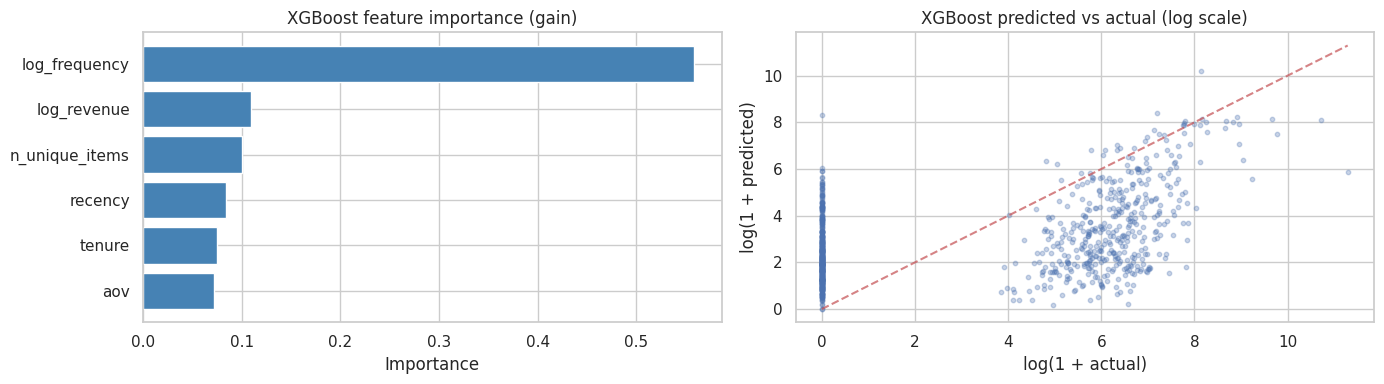

In [27]:
# Feature importance + diagnostic
imp = pd.DataFrame({
    'feature': feature_cols_ltv,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].barh(imp['feature'], imp['importance'], color='steelblue')
axes[0].set_title('XGBoost feature importance (gain)')
axes[0].set_xlabel('Importance')

axes[1].scatter(np.log1p(y_test), np.log1p(y_pred), alpha=0.3, s=10)
lim = [0, max(np.log1p(y_test).max(), np.log1p(y_pred).max())]
axes[1].plot(lim, lim, 'r--', alpha=0.7)
axes[1].set_xlabel('log(1 + actual)'); axes[1].set_ylabel('log(1 + predicted)')
axes[1].set_title('XGBoost predicted vs actual (log scale)')
plt.tight_layout()
plt.show()

## 7.3 LTV — Deep Learning: LSTM with Early Stopping

LSTM is sequence-aware model that pick up trajectory information that aggregated RFM hides. For LTV, *whether* spending is accelerating, decelerating or stable is a sequence question. LSTMs are also  faster to train other than transformers on short sequences.

LSTM input: X=(3701, 12, 3), y=(3701,)
Epoch  1  train MSE: 19.2174  val MSE: 18.3649  (best)
Epoch  2  train MSE: 18.3417  val MSE: 17.5124  (best)
Epoch  3  train MSE: 17.0699  val MSE: 15.9129  (best)
Epoch  4  train MSE: 14.7350  val MSE: 12.7552  (best)
Epoch  5  train MSE: 11.2802  val MSE: 9.4999  (best)
Epoch  6  train MSE: 9.2691  val MSE: 8.8630  (best)
Epoch  7  train MSE: 8.9534  val MSE: 8.6655  (best)
Epoch  8  train MSE: 8.7974  val MSE: 8.4957  (best)
Epoch  9  train MSE: 8.6063  val MSE: 8.3908  (best)
Epoch 10  train MSE: 8.5677  val MSE: 8.3157  (best)
Epoch 11  train MSE: 8.4342  val MSE: 8.2865  (best)
Epoch 12  train MSE: 8.4862  val MSE: 8.2667  (best)
Epoch 13  train MSE: 8.4161  val MSE: 8.2503  (best)
Epoch 14  train MSE: 8.3919  val MSE: 8.2565
Epoch 15  train MSE: 8.4293  val MSE: 8.2534
Epoch 16  train MSE: 8.3435  val MSE: 8.2254  (best)
Epoch 17  train MSE: 8.3804  val MSE: 8.2397
Epoch 18  train MSE: 8.3605  val MSE: 8.2265
Epoch 19  train MSE: 8.3069  v

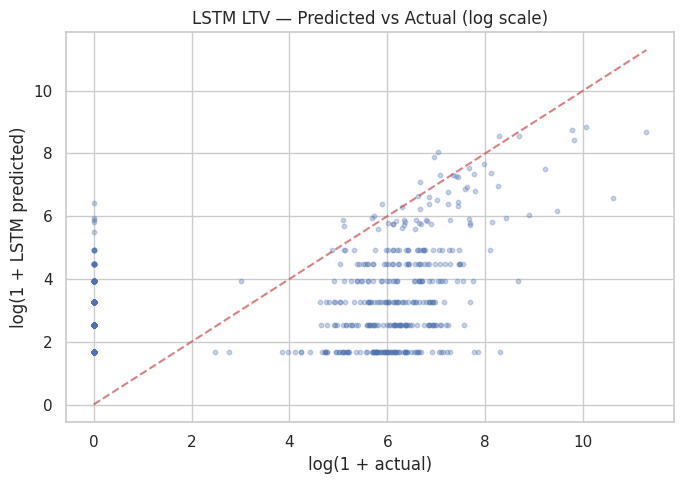

In [28]:
# Monthly sequences from the transformer block, align with LTV labels
cid_to_seq = {cid: (seqs[i], masks[i]) for i, cid in enumerate(cids)}

ltv_seq_X, ltv_seq_M, ltv_seq_y = [], [], []
for _, row in ltv_df.iterrows():
    cid = row['Customer ID']
    if cid in cid_to_seq:
        s, m = cid_to_seq[cid]
        ltv_seq_X.append(s); ltv_seq_M.append(m)
        ltv_seq_y.append(np.log1p(row['future_revenue_window']))
ltv_seq_X = np.stack(ltv_seq_X); ltv_seq_M = np.stack(ltv_seq_M)
ltv_seq_y = np.array(ltv_seq_y, dtype=np.float32)
print(f'LSTM input: X={ltv_seq_X.shape}, y={ltv_seq_y.shape}')

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.permutation(len(ltv_seq_y))
n = len(idx)
tr_end = int(0.65 * n)
va_end = int(0.80 * n)
tr, va, te = idx[:tr_end], idx[tr_end:va_end], idx[va_end:]

class LTVSeqDS(Dataset):
    def __init__(self, X, M, y): self.X, self.M, self.y = X, M, y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i]),
                torch.from_numpy(self.M[i].astype(np.float32)),
                torch.tensor(self.y[i]))

tr_dl = DataLoader(LTVSeqDS(ltv_seq_X[tr], ltv_seq_M[tr], ltv_seq_y[tr]), batch_size=128, shuffle=True)
va_dl = DataLoader(LTVSeqDS(ltv_seq_X[va], ltv_seq_M[va], ltv_seq_y[va]), batch_size=256)
te_dl = DataLoader(LTVSeqDS(ltv_seq_X[te], ltv_seq_M[te], ltv_seq_y[te]), batch_size=256)

class LTVLSTM(nn.Module):
    def __init__(self, feat_dim=3, hidden=32, n_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(feat_dim, hidden, n_layers, batch_first=True, dropout=0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 16), nn.ReLU(), nn.Dropout(dropout), nn.Linear(16, 1))
    def forward(self, x, mask):
        out, _ = self.lstm(x)
        last_idx = (mask.sum(dim=1) - 1).clamp(min=0).long()
        gathered = out[torch.arange(out.size(0)), last_idx]
        return self.head(gathered).squeeze(-1)

torch.manual_seed(RANDOM_STATE)
model = LTVLSTM().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
loss_fn = nn.MSELoss()

def eval_ltv(dl):
    model.eval(); preds, ys = [], []
    with torch.no_grad():
        for X, M, y in dl:
            X, M = X.to(device), M.to(device)
            preds.append(model(X, M).cpu().numpy())
            ys.append(y.numpy())
    return np.concatenate(preds), np.concatenate(ys)

best_val_loss = float('inf')
best_state = None
patience = 4; no_improve = 0
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train(); tot = 0
    for X, M, y in tr_dl:
        X, M, y = X.to(device), M.to(device), y.to(device)
        opt.zero_grad()
        pred = model(X, M)
        loss = loss_fn(pred, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tot += loss.item() * len(y)
    val_preds, val_ys = eval_ltv(va_dl)
    val_loss = np.mean((val_preds - val_ys) ** 2)
    scheduler.step(val_loss)
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
    print(f'Epoch {epoch+1:2d}  train MSE: {tot/len(tr):.4f}  val MSE: {val_loss:.4f}'
          f'{"  (best)" if no_improve == 0 else ""}')
    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch+1}.')
        break

model.load_state_dict(best_state)
preds, ys = eval_ltv(te_dl)
preds_pounds = np.clip(np.expm1(preds), 0, None)
ys_pounds = np.expm1(ys)

lstm_mae = np.mean(np.abs(preds_pounds - ys_pounds))
lstm_r2 = r2_score(ys_pounds, preds_pounds)
spear_lstm = spearmanr(ys_pounds, preds_pounds).correlation

print(f'\nLSTM LTV test results:')
print(f'  MAE:      £{lstm_mae:.2f}')
print(f'  R^2:      {lstm_r2:.3f}')
print(f'  Spearman: {spear_lstm:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log1p(ys_pounds), np.log1p(preds_pounds), alpha=0.3, s=10)
lim = [0, max(np.log1p(ys_pounds).max(), np.log1p(preds_pounds).max())]
ax.plot(lim, lim, 'r--', alpha=0.7)
ax.set_xlabel('log(1 + actual)'); ax.set_ylabel('log(1 + LSTM predicted)')
ax.set_title('LSTM LTV — Predicted vs Actual (log scale)')
plt.tight_layout()
plt.show()

# 8. Robust Evaluation — CV + Time-Based Holdout
1. **Stratified 5-fold CV on customers**: measures variance and gives confidence intervals.
2. **Time-based holdout**: train on data ending T-120, test on the latest 60 days.

In [29]:
from sklearn.model_selection import StratifiedKFold

feature_cols_eval = ['recency', 'tenure', 'log_frequency', 'log_revenue',
                     'aov', 'n_unique_items']
X_all = feat[feature_cols_eval].fillna(0).values
y_all = (1 - feat['retained']).values  # churn label

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {'logreg': [], 'lightgbm': []}

for fold, (tr_i, te_i) in enumerate(skf.split(X_all, y_all), 1):
    X_tr, X_te = X_all[tr_i], X_all[te_i]
    y_tr, y_te = y_all[tr_i], y_all[te_i]

    sc = StandardScaler().fit(X_tr)
    lr_m = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc.transform(X_tr), y_tr)
    lr_p = lr_m.predict_proba(sc.transform(X_te))[:, 1]
    results['logreg'].append(roc_auc_score(y_te, lr_p))

    lgbm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                              random_state=RANDOM_STATE, verbosity=-1).fit(X_tr, y_tr)
    lgb_p = lgbm.predict_proba(X_te)[:, 1]
    results['lightgbm'].append(roc_auc_score(y_te, lgb_p))

    print(f'Fold {fold}: LogReg AUC={results["logreg"][-1]:.3f}   LightGBM AUC={results["lightgbm"][-1]:.3f}')

print('\n5-fold CV summary (mean ± std):')
for k, v in results.items():
    print(f'  {k:>10s}: {np.mean(v):.3f} ± {np.std(v):.3f}   range=[{min(v):.3f}, {max(v):.3f}]')

Fold 1: LogReg AUC=0.709   LightGBM AUC=0.668
Fold 2: LogReg AUC=0.738   LightGBM AUC=0.699
Fold 3: LogReg AUC=0.737   LightGBM AUC=0.714
Fold 4: LogReg AUC=0.721   LightGBM AUC=0.682
Fold 5: LogReg AUC=0.702   LightGBM AUC=0.684

5-fold CV summary (mean ± std):
      logreg: 0.721 ± 0.014   range=[0.702, 0.738]
    lightgbm: 0.689 ± 0.016   range=[0.668, 0.714]


              Model  CV Mean AUC  CV Std  Time-Holdout AUC  CV - Holdout Gap
Logistic Regression        0.721   0.014             0.716             0.005
           LightGBM        0.689   0.016             0.689             0.001


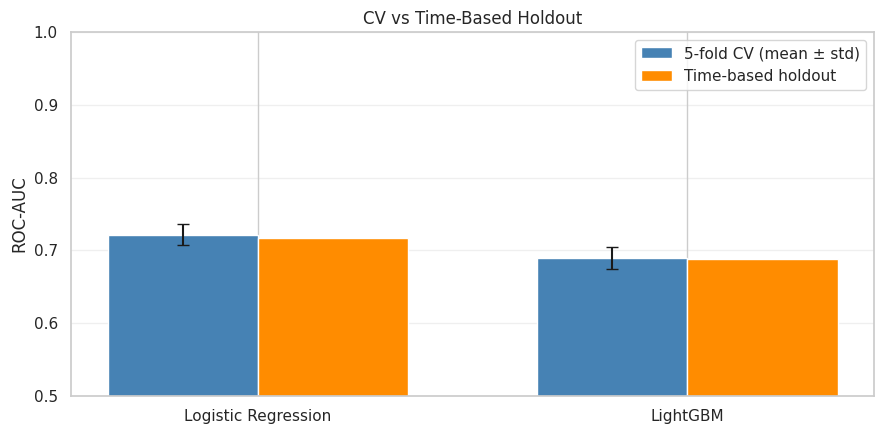

In [30]:
# Time-based holdout
early_cutoff = snapshot_date - pd.Timedelta(days=2 * WINDOW_DAYS)
mid_cutoff = snapshot_date - pd.Timedelta(days=WINDOW_DAYS)

def build_feat(tx, snap):
    f = tx.groupby('Customer ID').agg(
        frequency=('Invoice', 'nunique'),
        total_revenue=('Revenue', 'sum'),
        n_unique_items=('StockCode', 'nunique'),
        last_purchase=('InvoiceDate', 'max'),
        first_purchase=('InvoiceDate', 'min'),
    ).reset_index()
    f['recency'] = (snap - f['last_purchase']).dt.days
    f['tenure'] = (snap - f['first_purchase']).dt.days
    f['aov'] = f['total_revenue'] / f['frequency']
    f['log_revenue'] = np.log1p(f['total_revenue'])
    f['log_frequency'] = np.log1p(f['frequency'])
    return f

train_feat_tx = df_clean[df_clean['InvoiceDate'] < early_cutoff]
train_outcome_tx = df_clean[(df_clean['InvoiceDate'] >= early_cutoff) &
                            (df_clean['InvoiceDate'] < mid_cutoff)]
train_feat = build_feat(train_feat_tx, early_cutoff)
train_active = set(train_outcome_tx['Customer ID'].unique())
train_feat['churned'] = (~train_feat['Customer ID'].isin(train_active)).astype(int)

test_feat_tx = df_clean[df_clean['InvoiceDate'] < mid_cutoff]
test_outcome_tx = df_clean[df_clean['InvoiceDate'] >= mid_cutoff]
test_feat = build_feat(test_feat_tx, mid_cutoff)
test_active = set(test_outcome_tx['Customer ID'].unique())
test_feat['churned'] = (~test_feat['Customer ID'].isin(test_active)).astype(int)

X_tr = train_feat[feature_cols_eval].fillna(0).values
y_tr = train_feat['churned'].values
X_te = test_feat[feature_cols_eval].fillna(0).values
y_te = test_feat['churned'].values

sc = StandardScaler().fit(X_tr)
lr_holdout_auc = roc_auc_score(y_te, LogisticRegression(max_iter=1000, class_weight='balanced')
                               .fit(sc.transform(X_tr), y_tr)
                               .predict_proba(sc.transform(X_te))[:, 1])
lgb_holdout_auc = roc_auc_score(y_te, lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    random_state=RANDOM_STATE, verbosity=-1).fit(X_tr, y_tr).predict_proba(X_te)[:, 1])

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM'],
    'CV Mean AUC': [np.mean(results['logreg']), np.mean(results['lightgbm'])],
    'CV Std': [np.std(results['logreg']), np.std(results['lightgbm'])],
    'Time-Holdout AUC': [lr_holdout_auc, lgb_holdout_auc],
    'CV - Holdout Gap': [np.mean(results['logreg']) - lr_holdout_auc,
                         np.mean(results['lightgbm']) - lgb_holdout_auc]
}).round(3)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
models_n = ['Logistic Regression', 'LightGBM']
x = np.arange(len(models_n))
width = 0.35
cv_means = [np.mean(results['logreg']), np.mean(results['lightgbm'])]
cv_stds = [np.std(results['logreg']), np.std(results['lightgbm'])]
holdouts = [lr_holdout_auc, lgb_holdout_auc]
ax.bar(x - width/2, cv_means, width, yerr=cv_stds, label='5-fold CV (mean ± std)',
       color='steelblue', capsize=4)
ax.bar(x + width/2, holdouts, width, label='Time-based holdout', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(models_n); ax.set_ylabel('ROC-AUC')
ax.set_title('CV vs Time-Based Holdout')
ax.set_ylim(0.5, 1.0)
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 9. Business Action Layer — Prioritized Customer List

1. **Predicted CLV** (from BG/NBD + Gamma-Gamma) — how much they're worth
2. **Churn probability** (from LightGBM) — how likely they are to leave
3. **K-Means cluster** + RFM segment — what kind of customer they are

Each customer gets a **recommended action** based on their position in the value × risk grid and an **expected ROI**.

In [31]:
# Unified scoring table
action_df = customer_df[['Customer ID', 'recency_days', 'frequency', 'total_revenue',
                         'segment', 'cluster_label', 'country']].copy()

# Merging BG/NBD predicted CLV
action_df = action_df.merge(
    clv_summary[['pred_clv_window']].reset_index(),
    on='Customer ID', how='left'
)
action_df = action_df.rename(columns={'pred_clv_window': 'predicted_60d_clv'})
action_df['predicted_60d_clv'] = action_df['predicted_60d_clv'].fillna(0)

# Merging LightGBM churn probability by scoring the FULL customer base, not just test set
# Features for every customer in the time-aware feature window
all_X = feat_churn[feature_cols_lgb].fillna(0)
churn_proba_all = best_lgbm.predict_proba(all_X)[:, 1]
proba_df = pd.DataFrame({'Customer ID': feat_churn['Customer ID'].values,
                         'churn_probability': churn_proba_all})
action_df = action_df.merge(proba_df, on='Customer ID', how='left')
# Customers who only appear in the outcome window (won't have a feature-window score)
action_df['churn_probability'] = action_df['churn_probability'].fillna(action_df['churn_probability'].median())

# Value × Risk grid
action_df['value_tier'] = pd.qcut(
    action_df['predicted_60d_clv'].rank(method='first'),
    q=3, labels=['Low value', 'Mid value', 'High value']
)
action_df['risk_tier'] = pd.qcut(
    action_df['churn_probability'].rank(method='first'),
    q=3, labels=['Low risk', 'Mid risk', 'High risk']
)

# Action recommendation matrix
def recommend_action(row):
    v, r = str(row['value_tier']), str(row['risk_tier'])
    if v == 'High value' and r == 'High risk':
        return 'URGENT: Personal outreach + retention offer'
    if v == 'High value' and r == 'Mid risk':
        return 'Proactive: VIP touchpoint, no discount'
    if v == 'High value' and r == 'Low risk':
        return 'Maintain: Loyalty perk, thank-you gesture'
    if v == 'Mid value' and r == 'High risk':
        return 'Save: Targeted discount or reactivation email'
    if v == 'Mid value' and r == 'Mid risk':
        return 'Nurture: Cross-sell / category recommendation'
    if v == 'Mid value' and r == 'Low risk':
        return 'Standard: Regular newsletter cadence'
    if v == 'Low value' and r == 'High risk':
        return 'Low priority: Single win-back email'
    if v == 'Low value' and r == 'Mid risk':
        return 'Light touch: Newsletter only'
    return 'Monitor: No action'

action_df['recommended_action'] = action_df.apply(recommend_action, axis=1)
# Expected return on a £1 retention email assuming 20% effectiveness lift on save
EMAIL_COST = 0.20
LIFT = 0.20  # assumed effectiveness of retention intervention
action_df['expected_save_value'] = (
    action_df['churn_probability'] * action_df['predicted_60d_clv'] * LIFT
)
action_df['expected_roi'] = (action_df['expected_save_value'] - EMAIL_COST) / EMAIL_COST

# Action grid summary
grid = action_df.groupby(['value_tier', 'risk_tier'], observed=True).agg(
    customers=('Customer ID', 'count'),
    avg_clv=('predicted_60d_clv', 'mean'),
    avg_churn_prob=('churn_probability', 'mean'),
    total_expected_save=('expected_save_value', 'sum')
).round(2)
print('Value × Risk action grid:')
print(grid)

Value × Risk action grid:
                      customers  avg_clv  avg_churn_prob  total_expected_save
value_tier risk_tier                                                         
Low value  Low risk          17     0.00            0.43                 0.00
           Mid risk         628     0.00            0.60                 0.00
           High risk        792     0.00            0.77                 0.00
Mid value  Low risk         635   262.56            0.32             10386.50
           Mid risk         394   225.82            0.59             10452.50
           High risk        408   191.51            0.74             11479.36
High value Low risk         785  1341.95            0.23             36437.00
           Mid risk         415  1196.49            0.59             58396.15
           High risk        238   954.72            0.73             33299.48


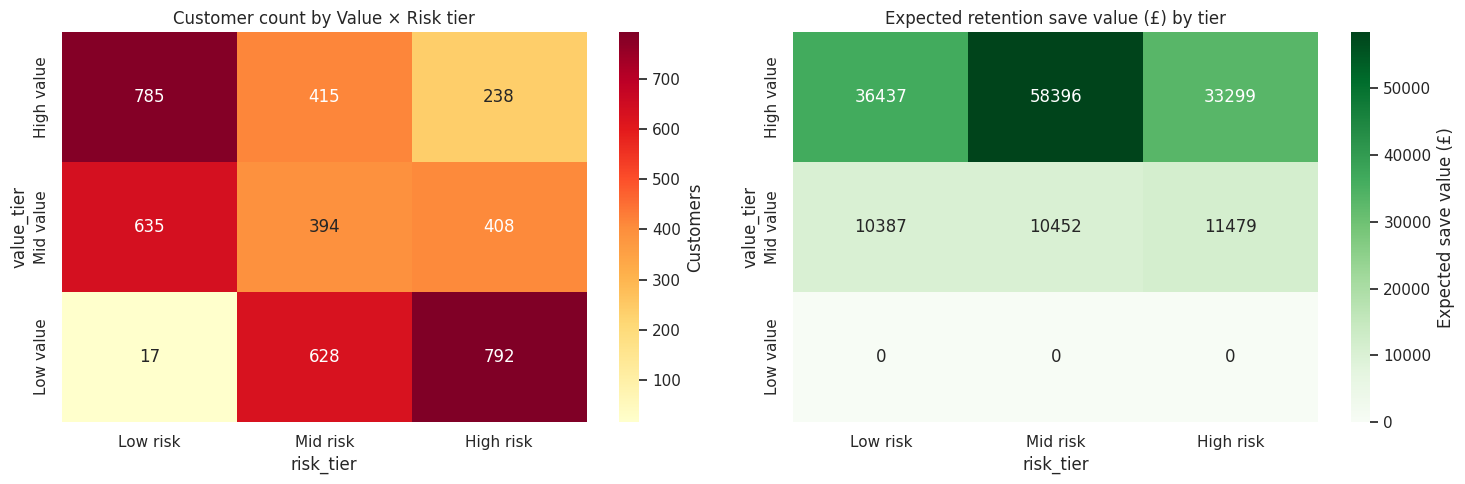

In [32]:
# Visualize action grid
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap of customer counts by tier
pivot_count = action_df.pivot_table(
    index='value_tier', columns='risk_tier', values='Customer ID',
    aggfunc='count', observed=True
).reindex(index=['High value', 'Mid value', 'Low value'],
          columns=['Low risk', 'Mid risk', 'High risk'])
sns.heatmap(pivot_count, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Customers'})
axes[0].set_title('Customer count by Value × Risk tier')

# Heatmap of expected save value
pivot_save = action_df.pivot_table(
    index='value_tier', columns='risk_tier', values='expected_save_value',
    aggfunc='sum', observed=True
).reindex(index=['High value', 'Mid value', 'Low value'],
         columns=['Low risk', 'Mid risk', 'High risk'])
sns.heatmap(pivot_save, annot=True, fmt='.0f', cmap='Greens', ax=axes[1],
            cbar_kws={'label': 'Expected save value (£)'})
axes[1].set_title('Expected retention save value (£) by tier')

plt.tight_layout()
plt.show()

In [33]:
# Top 30 priority customers
priority_list = action_df[
    (action_df['value_tier'] == 'High value') & (action_df['risk_tier'] == 'High risk')
].sort_values('expected_save_value', ascending=False).head(30)

print(f'TOP 30 PRIORITY CUSTOMERS (High value × High risk)')
print(f'Total expected save value if all are reached: £{priority_list["expected_save_value"].sum():,.2f}')
print(f'Email cost (30 × £{EMAIL_COST}): £{30*EMAIL_COST:.2f}')
print(f'Net expected return: £{priority_list["expected_save_value"].sum() - 30*EMAIL_COST:,.2f}')
print()
print(priority_list[['Customer ID', 'segment', 'cluster_label', 'country',
                     'predicted_60d_clv', 'churn_probability', 'expected_save_value',
                     'recommended_action']].to_string(index=False))

# List to CSV
action_df.to_csv('customer_action_list.csv', index=False)
print(f'\nFull action list saved to customer_action_list.csv ({len(action_df):,} customers)')

TOP 30 PRIORITY CUSTOMERS (High value × High risk)
Total expected save value if all are reached: £11,740.82
Email cost (30 × £0.2): £6.00
Net expected return: £11,734.82

 Customer ID             segment       cluster_label         country  predicted_60d_clv  churn_probability  expected_save_value                          recommended_action
       13902             At Risk High-value / Active         Denmark        7093.630523           0.801705          1137.399180 URGENT: Personal outreach + retention offer
       14091         Hibernating Low-value / Dormant  United Kingdom        5069.293524           0.848806           860.569486 URGENT: Personal outreach + retention offer
       12744             At Risk High-value / Active       Singapore        4876.771251           0.688529           671.559426 URGENT: Personal outreach + retention offer
       12482             At Risk High-value / Active          Sweden        4074.045297           0.756379           616.304245 URGENT: Perso

- The **Top 30 priority list** is the immediate action queue. These are High-value × High-risk customers with the largest expected ROI.
- The **value × risk heatmap** are budget envelopes where  retention spend can be allocated top-down, top-row-first until the marginal expected save value falls below the cost-per-touch.
- High-value/High-risk gets personal outreach (expensive but worth it); Low-value/High-risk gets a single automated email.
- The full `customer_action_list.csv` includes every customer with their segment, cluster, predicted CLV, churn probability and recommended action.
- Calibrate the `LIFT` parameter against historical campaign A/B test data
- Stratify lift by segment as Champions are likely less responsive to discounts than At Risk customers.
- Include the **time-to-churn** estimate from the Weibull AFT model to prioritize campaign timing within the High-risk tier.

## Business Deliverables

1. **Customer segmentation** (RFM rules + K-Means): every customer is named and grouped.
2. **Risk scores**: every active customer has a churn probability and a 60-day CLV estimate.
3. **Prioritized action list**: combining value × risk into recommended actions with expected ROI.
4. **Robust evaluation**: CV + time-based holdout to make sure the production-deployed metric matches the reported one.

## Executive summary

A retention email costs £0.20. An at-risk High-value customer is worth £25-200+ in expected 60-day revenue. The model identifies the top decile of High-value × High-risk customers and quantifies expected save value per intervention. The marketing team can now spend retention budget where it has the highest expected ROI instead of broadcasting to the entire base.